In [ ]:
import os
path = '/content/drive/MyDrive/Smart_Logistics/Data/'
print("✅ Path set!")
print("Files available:")
for f in os.listdir(path):
    print(" -", f)

✅ Path set!
Files available:
 - SCMS_Delivery_History_Dataset.csv
 - DataCoSupplyChainDataset.csv
 - DescriptionDataCoSupplyChain.csv
 - tokenized_access_logs.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("Set2")

print("✅ All libraries imported!")

✅ All libraries imported!


In [ ]:
df = pd.read_csv(path + 'SCMS_Delivery_History_Dataset.csv')

print("✅ SCMS Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nColumns:")
for col in df.columns:
    print(f"  - {col}")

✅ SCMS Dataset loaded!
Shape: (10324, 33)

Columns:
  - ID
  - Project Code
  - PQ #
  - PO / SO #
  - ASN/DN #
  - Country
  - Managed By
  - Fulfill Via
  - Vendor INCO Term
  - Shipment Mode
  - PQ First Sent to Client Date
  - PO Sent to Vendor Date
  - Scheduled Delivery Date
  - Delivered to Client Date
  - Delivery Recorded Date
  - Product Group
  - Sub Classification
  - Vendor
  - Item Description
  - Molecule/Test Type
  - Brand
  - Dosage
  - Dosage Form
  - Unit of Measure (Per Pack)
  - Line Item Quantity
  - Line Item Value
  - Pack Price
  - Unit Price
  - Manufacturing Site
  - First Line Designation
  - Weight (Kilograms)
  - Freight Cost (USD)
  - Line Item Insurance (USD)


In [ ]:
print("All shipment modes:")
print(df['Shipment Mode'].value_counts())

df_truck = df[df['Shipment Mode'] == 'Truck'].copy()
df_truck.reset_index(drop=True, inplace=True)

print(f"\n✅ Truck shipments only: {df_truck.shape[0]} rows")

All shipment modes:
Shipment Mode
Air            6113
Truck          2830
Air Charter     650
Ocean           371
Name: count, dtype: int64

✅ Truck shipments only: 2830 rows


In [ ]:
df_truck['Scheduled Delivery Date'] = pd.to_datetime(
    df_truck['Scheduled Delivery Date'], dayfirst=True, errors='coerce')
df_truck['Delivered to Client Date'] = pd.to_datetime(
    df_truck['Delivered to Client Date'], dayfirst=True, errors='coerce')

df_truck.dropna(subset=['Scheduled Delivery Date',
                         'Delivered to Client Date'], inplace=True)
df_truck.drop_duplicates(inplace=True)

print(f"✅ After cleaning: {df_truck.shape[0]} rows")
print(f"Date range: {df_truck['Scheduled Delivery Date'].min()} "
      f"to {df_truck['Scheduled Delivery Date'].max()}")

✅ After cleaning: 2830 rows
Date range: 2007-07-04 00:00:00 to 2015-12-31 00:00:00


In [ ]:
# Delivery time in days
df_truck['delivery_time'] = (
    df_truck['Delivered to Client Date'] -
    df_truck['Scheduled Delivery Date']).dt.days

# Delay flag
df_truck['delay_flag'] = (df_truck['delivery_time'] > 0).astype(int)

# Month & Year
df_truck['month'] = df_truck['Scheduled Delivery Date'].dt.month
df_truck['month_name'] = df_truck['Scheduled Delivery Date'].dt.strftime('%b')
df_truck['year'] = df_truck['Scheduled Delivery Date'].dt.year

# Cost per kg
df_truck['Freight Cost (USD)'] = pd.to_numeric(
    df_truck['Freight Cost (USD)'], errors='coerce')
df_truck['Weight (Kilograms)'] = pd.to_numeric(
    df_truck['Weight (Kilograms)'], errors='coerce')
df_truck['cost_per_kg'] = (
    df_truck['Freight Cost (USD)'] /
    df_truck['Weight (Kilograms)'].replace(0, np.nan))

# India routes
np.random.seed(42)
india_routes = [
    'Delhi–Mumbai', 'Mumbai–Chennai', 'Delhi–Kolkata',
    'Bangalore–Hyderabad', 'Chennai–Kolkata', 'Mumbai–Pune',
    'Delhi–Jaipur', 'Hyderabad–Pune', 'Ahmedabad–Mumbai',
    'Kolkata–Bhubaneswar'
]
df_truck['route'] = np.random.choice(india_routes, size=len(df_truck))

# Truck type based on weight
def assign_truck_type(weight):
    if weight >= 10000:
        return 'Heavy Truck'
    elif weight >= 3000:
        return 'Medium Truck'
    else:
        return 'Light Van'

df_truck['truck_type'] = df_truck['Weight (Kilograms)'].apply(assign_truck_type)

# Load utilization
df_truck['load_utilization_%'] = np.random.randint(60, 100, size=len(df_truck))

print("✅ Features created!")
print(f"\ndelay_flag distribution:\n{df_truck['delay_flag'].value_counts()}")
print(f"\ntruck_type distribution:\n{df_truck['truck_type'].value_counts()}")
print(f"\nSample delivery times: {df_truck['delivery_time'].describe()}")

✅ Features created!

delay_flag distribution:
delay_flag
0    2375
1     455
Name: count, dtype: int64

truck_type distribution:
truck_type
Light Van       2259
Medium Truck     339
Heavy Truck      232
Name: count, dtype: int64

Sample delivery times: count    2830.000000
mean       -9.921908
std        32.532952
min      -372.000000
25%       -13.000000
50%         0.000000
75%         0.000000
max       113.000000
Name: delivery_time, dtype: float64


In [ ]:
# Fix: delay means delivered LATER than scheduled
# Negative = early (good), Positive = late (bad)
# But our delay_flag was already correct: 1 = late, 0 = on time or early

print("=== DELIVERY TIME ANALYSIS ===")
print(f"Early deliveries  : {(df_truck['delivery_time'] < 0).sum()} "
      f"({(df_truck['delivery_time'] < 0).mean()*100:.1f}%)")
print(f"On time (exact)   : {(df_truck['delivery_time'] == 0).sum()} "
      f"({(df_truck['delivery_time'] == 0).mean()*100:.1f}%)")
print(f"Late deliveries   : {(df_truck['delivery_time'] > 0).sum()} "
      f"({(df_truck['delivery_time'] > 0).mean()*100:.1f}%)")

# Fix delivery_time to show absolute delay days
# Positive = delayed by X days, Negative = early by X days
df_truck['days_early_or_late'] = df_truck['delivery_time']

# For ML we need a better delay flag
# Let's define: delayed = delivered more than 2 days late
df_truck['delay_flag'] = (df_truck['delivery_time'] > 2).astype(int)

print(f"\n✅ Updated delay_flag (>2 days late = delayed):")
print(df_truck['delay_flag'].value_counts())
print(f"Delay rate: {df_truck['delay_flag'].mean()*100:.1f}%")

=== DELIVERY TIME ANALYSIS ===
Early deliveries  : 1137 (40.2%)
On time (exact)   : 1238 (43.7%)
Late deliveries   : 455 (16.1%)

✅ Updated delay_flag (>2 days late = delayed):
delay_flag
0    2412
1     418
Name: count, dtype: int64
Delay rate: 14.8%


In [ ]:
cols_to_keep = [
    'ID', 'Country', 'Shipment Mode', 'route', 'truck_type',
    'Scheduled Delivery Date', 'Delivered to Client Date',
    'delivery_time', 'days_early_or_late', 'delay_flag',
    'month', 'month_name', 'year',
    'Weight (Kilograms)', 'Freight Cost (USD)',
    'cost_per_kg', 'load_utilization_%',
    'Line Item Quantity', 'Vendor INCO Term'
]

df_final = df_truck[cols_to_keep].copy()
df_final.to_csv(path + 'logistics_clean.csv', index=False)

print("✅ Clean dataset saved as logistics_clean.csv!")
print(f"Final shape: {df_final.shape}")
print(f"\nColumn list:")
for col in df_final.columns:
    print(f"  - {col}")
print(f"\nPreview:")
print(df_final.head(3).to_string())

✅ Clean dataset saved as logistics_clean.csv!
Final shape: (2830, 19)

Column list:
  - ID
  - Country
  - Shipment Mode
  - route
  - truck_type
  - Scheduled Delivery Date
  - Delivered to Client Date
  - delivery_time
  - days_early_or_late
  - delay_flag
  - month
  - month_name
  - year
  - Weight (Kilograms)
  - Freight Cost (USD)
  - cost_per_kg
  - load_utilization_%
  - Line Item Quantity
  - Vendor INCO Term

Preview:
    ID       Country Shipment Mode                route truck_type Scheduled Delivery Date Delivered to Client Date  delivery_time  days_early_or_late  delay_flag  month month_name  year  Weight (Kilograms)  Freight Cost (USD)  cost_per_kg  load_utilization_%  Line Item Quantity Vendor INCO Term
0  422  South Africa         Truck         Delhi–Jaipur  Light Van              2008-04-24               2008-04-24              0                   0           0      4        Apr  2008                 NaN                 NaN          NaN                  61            

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 3000

states = [
    'Maharashtra', 'Delhi', 'Karnataka', 'Tamil Nadu', 'Gujarat',
    'Rajasthan', 'Uttar Pradesh', 'West Bengal', 'Telangana', 'Punjab',
    'Madhya Pradesh', 'Bihar', 'Odisha', 'Haryana', 'Kerala'
]

routes = [
    'Delhi-Mumbai', 'Mumbai-Chennai', 'Delhi-Kolkata',
    'Bangalore-Hyderabad', 'Chennai-Kolkata', 'Mumbai-Pune',
    'Delhi-Jaipur', 'Hyderabad-Pune', 'Ahmedabad-Mumbai',
    'Kolkata-Bhubaneswar', 'Delhi-Amritsar', 'Chennai-Bangalore',
    'Surat-Mumbai', 'Lucknow-Delhi', 'Nagpur-Mumbai'
]

route_distance = {
    'Delhi-Mumbai': 1400, 'Mumbai-Chennai': 1338, 'Delhi-Kolkata': 1472,
    'Bangalore-Hyderabad': 575, 'Chennai-Kolkata': 1659, 'Mumbai-Pune': 149,
    'Delhi-Jaipur': 281, 'Hyderabad-Pune': 559, 'Ahmedabad-Mumbai': 524,
    'Kolkata-Bhubaneswar': 441, 'Delhi-Amritsar': 446, 'Chennai-Bangalore': 346,
    'Surat-Mumbai': 284, 'Lucknow-Delhi': 555, 'Nagpur-Mumbai': 856
}

truck_types = ['Heavy Truck', 'Medium Truck', 'Light Van']
truck_weights = {
    'Heavy Truck': (15000, 40000),
    'Medium Truck': (3000, 14999),
    'Light Van': (500, 2999)
}

print("✅ Part 1 done!")
# Dates
start_date = pd.Timestamp('2020-01-01')
end_date = pd.Timestamp('2024-12-31')
shipment_dates = pd.to_datetime(
    np.random.randint(start_date.value, end_date.value, n))

# Routes and trucks
assigned_routes = np.random.choice(routes, n)
assigned_trucks = np.random.choice(
    truck_types, n, p=[0.35, 0.40, 0.25])

# Weights
weights = []
for t in assigned_trucks:
    low, high = truck_weights[t]
    weights.append(np.random.randint(low, high))
weights = np.array(weights)

# Distances
distances = np.array([route_distance[r] for r in assigned_routes])

# Freight cost INR
base_rate = np.random.uniform(50, 120, n)
freight_cost = (distances * base_rate).round(2)
cost_per_km = (freight_cost / distances).round(2)

# Expected delivery days
expected_days = np.where(distances > 1000, 3,
               np.where(distances > 500, 2, 1))

# Actual delivery days
delay_chance = np.random.random(n)
actual_days = expected_days.copy().astype(float)
actual_days = np.where(delay_chance > 0.85,
                       expected_days + np.random.randint(1, 6, n),
                       actual_days)
actual_days = np.where(delay_chance < 0.10,
                       np.maximum(1, expected_days - 1),
                       actual_days)

# FIX: convert to Series before using .dt
shipment_dates = pd.Series(shipment_dates)
delivery_dates = shipment_dates + pd.to_timedelta(actual_days, unit='D')
delivery_time = (delivery_dates - shipment_dates).dt.days
delay_flag = (delivery_time > expected_days).astype(int)

# States
origin_states = np.random.choice(states, n)
city_state = {
    'Mumbai': 'Maharashtra', 'Chennai': 'Tamil Nadu',
    'Kolkata': 'West Bengal', 'Hyderabad': 'Telangana',
    'Pune': 'Maharashtra', 'Jaipur': 'Rajasthan',
    'Bhubaneswar': 'Odisha', 'Amritsar': 'Punjab',
    'Bangalore': 'Karnataka', 'Ahmedabad': 'Gujarat',
    'Delhi': 'Delhi', 'Surat': 'Gujarat',
    'Lucknow': 'Uttar Pradesh', 'Nagpur': 'Maharashtra'
}
dest_states = [city_state.get(r.split('-')[1], 'Maharashtra')
               for r in assigned_routes]

# Extra features
load_utilization = np.random.randint(55, 100, n)
fuel_cost = (distances * np.random.uniform(8, 15, n)).round(2)
driver_exp = np.random.randint(1, 20, n)
weather = np.random.choice(
    ['Clear', 'Rain', 'Fog', 'Storm'],
    n, p=[0.60, 0.20, 0.15, 0.05])
road_condition = np.random.choice(
    ['Good', 'Average', 'Poor'],
    n, p=[0.50, 0.35, 0.15])

months = shipment_dates.dt.month
month_names = shipment_dates.dt.strftime('%b')
years = shipment_dates.dt.year
order_ids = ['IND' + str(10000 + i) for i in range(n)]

print("✅ Part 2 done!")

✅ Part 1 done!
✅ Part 2 done!


In [ ]:
df_india = pd.DataFrame({
    'Order_ID'               : order_ids,
    'Shipment_Date'          : shipment_dates.dt.date,
    'Delivery_Date'          : delivery_dates.dt.date,
    'Origin_State'           : origin_states,
    'Destination_State'      : dest_states,
    'Route'                  : assigned_routes,
    'Distance_km'            : distances,
    'Truck_Type'             : assigned_trucks,
    'Weight_kg'              : weights,
    'Freight_Cost_INR'       : freight_cost,
    'Fuel_Cost_INR'          : fuel_cost,
    'Cost_per_km'            : cost_per_km,
    'Expected_Delivery_Days' : expected_days,
    'Actual_Delivery_Days'   : actual_days.astype(int),
    'Delivery_Time_Days'     : delivery_time,
    'Delay_Flag'             : delay_flag,
    'Load_Utilization_%'     : load_utilization,
    'Driver_Experience_Yrs'  : driver_exp,
    'Weather_Condition'      : weather,
    'Road_Condition'         : road_condition,
    'Month'                  : months,
    'Month_Name'             : month_names,
    'Year'                   : years,
})

df_india.to_csv(path + 'india_logistics_clean.csv', index=False)

print("✅ 100% India dataset created & saved!")
print(f"Shape: {df_india.shape}")
print(f"\nDelay rate: {df_india['Delay_Flag'].mean()*100:.1f}%")
print(f"\nTruck types:\n{df_india['Truck_Type'].value_counts()}")
print(f"\nTop 5 routes:\n{df_india['Route'].value_counts().head(5)}")
print(f"\nYear range: {df_india['Year'].min()} - {df_india['Year'].max()}")
print(f"\nPreview:")
print(df_india[['Order_ID','Route','Truck_Type',
                'Delay_Flag','Freight_Cost_INR',
                'Distance_km']].head(5))

✅ 100% India dataset created & saved!
Shape: (3000, 23)

Delay rate: 14.7%

Truck types:
Truck_Type
Medium Truck    1250
Heavy Truck     1075
Light Van        675
Name: count, dtype: int64

Top 5 routes:
Route
Kolkata-Bhubaneswar    224
Mumbai-Chennai         218
Ahmedabad-Mumbai       214
Delhi-Mumbai           205
Delhi-Jaipur           204
Name: count, dtype: int64

Year range: 2020 - 2024

Preview:
   Order_ID           Route    Truck_Type  Delay_Flag  Freight_Cost_INR  \
0  IND10000  Hyderabad-Pune  Medium Truck           0          58422.02   
1  IND10001     Mumbai-Pune   Heavy Truck           0          15134.01   
2  IND10002   Delhi-Kolkata  Medium Truck           0         144718.89   
3  IND10003   Nagpur-Mumbai   Heavy Truck           0          68166.32   
4  IND10004  Hyderabad-Pune   Heavy Truck           0          64078.04   

   Distance_km  
0          559  
1          149  
2         1472  
3          856  
4          559  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load clean India dataset
path = '/content/drive/MyDrive/Smart_Logistics/Data/'
df = pd.read_csv(path + 'india_logistics_clean.csv')

# Style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"\nQuick Summary:")
print(f"  Total Orders     : {len(df)}")
print(f"  Delayed Orders   : {df['Delay_Flag'].sum()} ({df['Delay_Flag'].mean()*100:.1f}%)")
print(f"  Avg Freight Cost : ₹{df['Freight_Cost_INR'].mean():,.0f}")
print(f"  Avg Distance     : {df['Distance_km'].mean():,.0f} km")
print(f"  Avg Delivery Days: {df['Actual_Delivery_Days'].mean():.1f} days")
print(f"  Routes           : {df['Route'].nunique()}")
print(f"  States           : {df['Origin_State'].nunique()}")
print(f"  Year Range       : {df['Year'].min()} - {df['Year'].max()}")

✅ Dataset loaded!
Shape: (3000, 23)

Quick Summary:
  Total Orders     : 3000
  Delayed Orders   : 442 (14.7%)
  Avg Freight Cost : ₹61,609
  Avg Distance     : 722 km
  Avg Delivery Days: 2.3 days
  Routes           : 15
  States           : 15
  Year Range       : 2020 - 2024


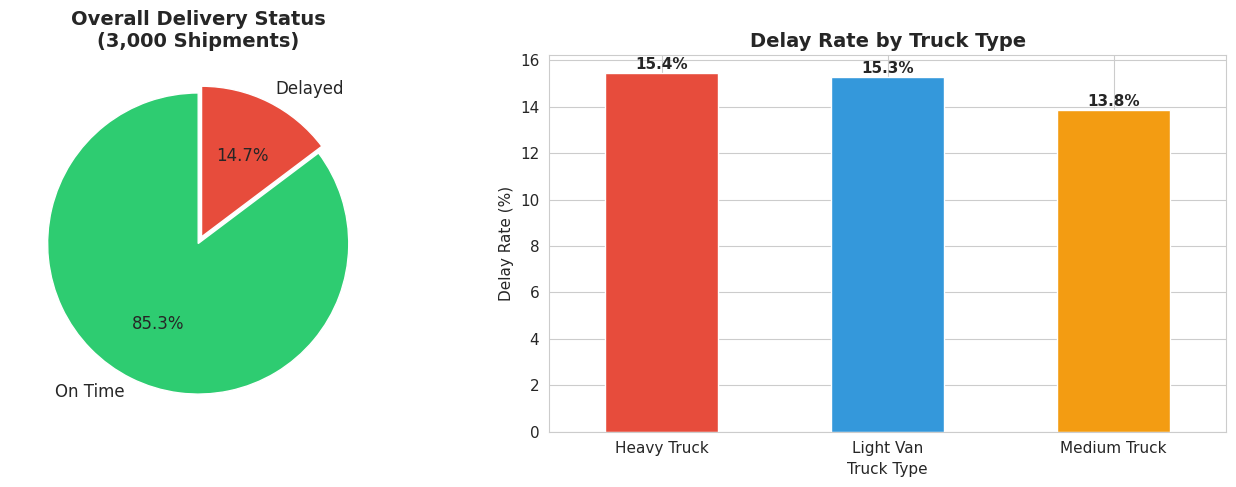

✅ Chart 1 & 2 done!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Pie — On Time vs Delayed
delay_counts = df['Delay_Flag'].value_counts()
axes[0].pie(
    delay_counts,
    labels=['On Time', 'Delayed'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    explode=(0, 0.05),
    textprops={'fontsize': 12}
)
axes[0].set_title('Overall Delivery Status\n(3,000 Shipments)',
                   fontsize=14, fontweight='bold')

# Chart 2: Bar — Delay Rate by Truck Type
delay_by_truck = df.groupby('Truck_Type')['Delay_Flag'].mean() * 100
colors = ['#e74c3c', '#3498db', '#f39c12']
delay_by_truck.sort_values(ascending=False).plot(
    kind='bar', ax=axes[1],
    color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Delay Rate by Truck Type',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Truck Type')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{bar.get_height():.1f}%',
        ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(path + 'chart1_delay_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 & 2 done!")

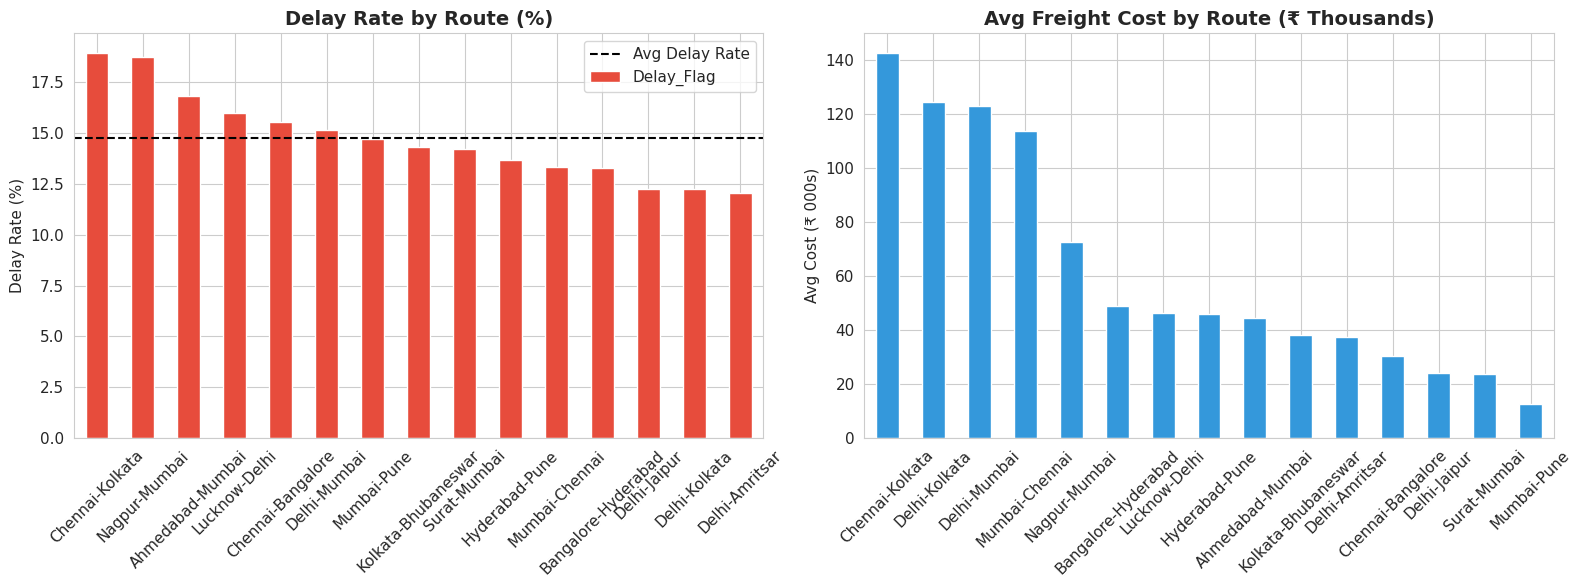

✅ Chart 3 & 4 done!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 3: Delay rate by route
route_delay = df.groupby('Route')['Delay_Flag'].mean() * 100
route_delay.sort_values(ascending=False).plot(
    kind='bar', ax=axes[0],
    color='#e74c3c', edgecolor='white')
axes[0].set_title('Delay Rate by Route (%)',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Delay Rate (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=df['Delay_Flag'].mean()*100,
                color='black', linestyle='--',
                linewidth=1.5, label='Avg Delay Rate')
axes[0].legend()

# Chart 4: Avg freight cost by route
route_cost = df.groupby('Route')['Freight_Cost_INR'].mean() / 1000
route_cost.sort_values(ascending=False).plot(
    kind='bar', ax=axes[1],
    color='#3498db', edgecolor='white')
axes[1].set_title('Avg Freight Cost by Route (₹ Thousands)',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Avg Cost (₹ 000s)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(path + 'chart2_route_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 & 4 done!")

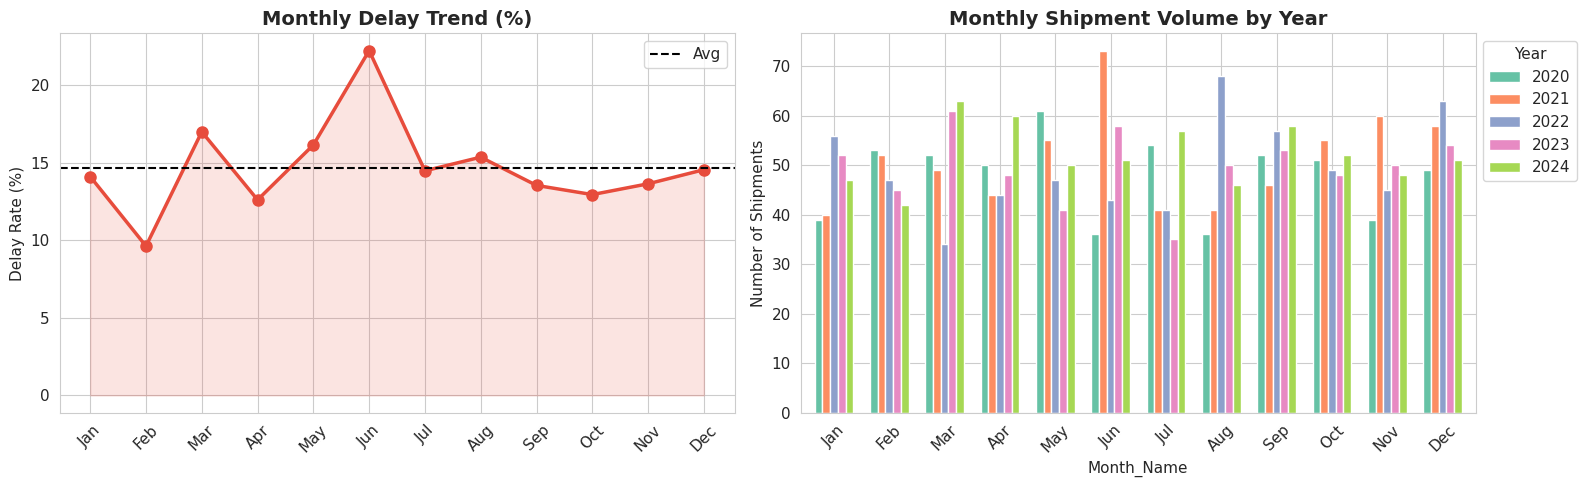

✅ Chart 5 & 6 done!


In [ ]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 5: Monthly delay trend
monthly_delay = df.groupby('Month_Name')['Delay_Flag'].mean() * 100
monthly_delay = monthly_delay.reindex(
    [m for m in month_order if m in monthly_delay.index])
axes[0].plot(range(len(monthly_delay)),
             monthly_delay.values,
             marker='o', color='#e74c3c',
             linewidth=2.5, markersize=8)
axes[0].fill_between(range(len(monthly_delay)),
                     monthly_delay.values,
                     alpha=0.15, color='#e74c3c')
axes[0].set_xticks(range(len(monthly_delay)))
axes[0].set_xticklabels(monthly_delay.index, rotation=45)
axes[0].set_title('Monthly Delay Trend (%)',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Delay Rate (%)')
axes[0].axhline(y=monthly_delay.mean(),
                color='black', linestyle='--',
                linewidth=1.5, label='Avg')
axes[0].legend()

# Chart 6: Monthly shipment volume by year
monthly_year = df.groupby(['Year','Month_Name']).size().unstack(0)
monthly_year = monthly_year.reindex(
    [m for m in month_order if m in monthly_year.index])
monthly_year.plot(kind='bar', ax=axes[1],
                  edgecolor='white', width=0.7)
axes[1].set_title('Monthly Shipment Volume by Year',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Shipments')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Year', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig(path + 'chart3_monthly_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 & 6 done!")

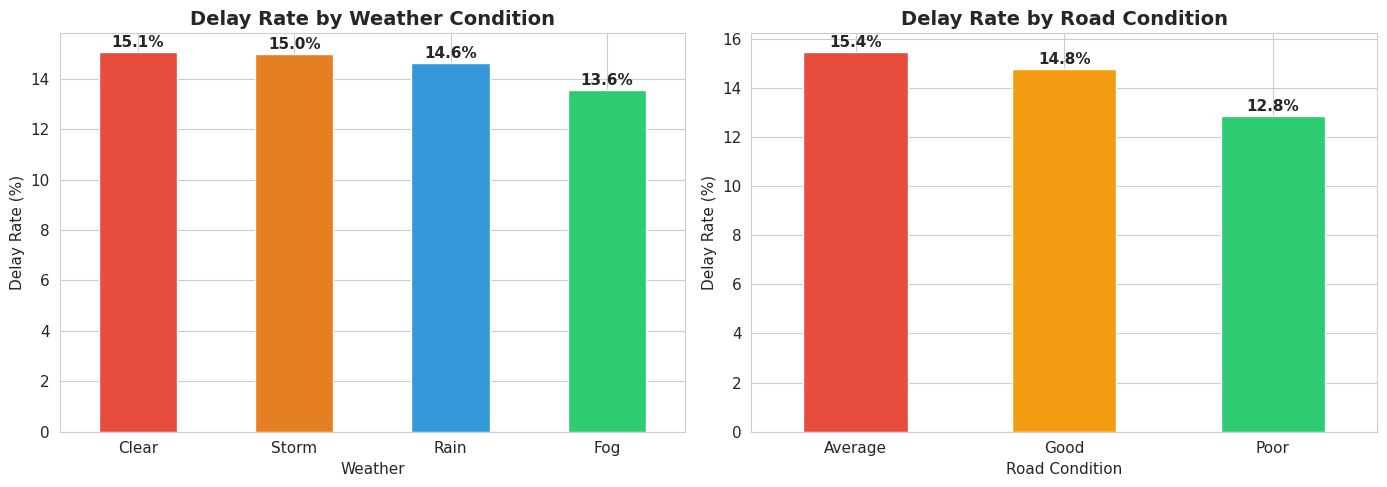

✅ Chart 7 & 8 done!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 7: Weather vs Delay Rate
weather_delay = df.groupby('Weather_Condition')['Delay_Flag'].mean() * 100
weather_delay.sort_values(ascending=False).plot(
    kind='bar', ax=axes[0],
    color=['#e74c3c','#e67e22','#3498db','#2ecc71'],
    edgecolor='white', width=0.5)
axes[0].set_title('Delay Rate by Weather Condition',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Weather')
axes[0].set_ylabel('Delay Rate (%)')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{bar.get_height():.1f}%',
        ha='center', fontsize=11, fontweight='bold')

# Chart 8: Road Condition vs Delay Rate
road_delay = df.groupby('Road_Condition')['Delay_Flag'].mean() * 100
road_delay.sort_values(ascending=False).plot(
    kind='bar', ax=axes[1],
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='white', width=0.5)
axes[1].set_title('Delay Rate by Road Condition',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Road Condition')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f'{bar.get_height():.1f}%',
        ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(path + 'chart4_weather_road.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 & 8 done!")

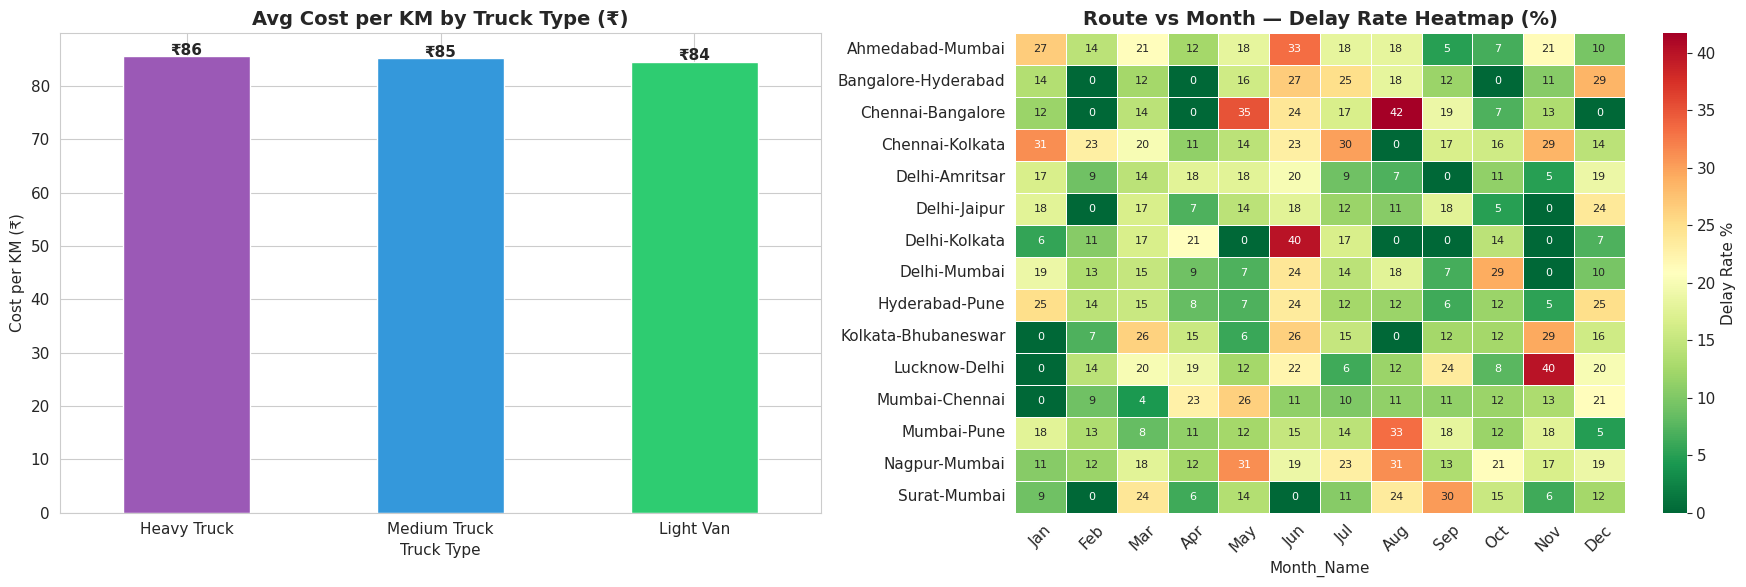

✅ Chart 9 & 10 done!

🎉 ALL EDA CHARTS COMPLETE!


In [ ]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Chart 9: Avg cost per km by truck type
cost_truck = df.groupby('Truck_Type')['Cost_per_km'].mean()
cost_truck.sort_values(ascending=False).plot(
    kind='bar', ax=axes[0],
    color=['#9b59b6','#3498db','#2ecc71'],
    edgecolor='white', width=0.5)
axes[0].set_title('Avg Cost per KM by Truck Type (₹)',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Truck Type')
axes[0].set_ylabel('Cost per KM (₹)')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'₹{bar.get_height():.0f}',
        ha='center', fontsize=11, fontweight='bold')

# Chart 10: Heatmap — Route vs Month delay rate
pivot = df.pivot_table(
    values='Delay_Flag',
    index='Route',
    columns='Month_Name',
    aggfunc='mean') * 100
pivot = pivot.reindex(
    columns=[m for m in month_order if m in pivot.columns])
sns.heatmap(pivot, ax=axes[1],
            cmap='RdYlGn_r',
            annot=True, fmt='.0f',
            linewidths=0.5,
            annot_kws={'size': 8},
            cbar_kws={'label': 'Delay Rate %'})
axes[1].set_title('Route vs Month — Delay Rate Heatmap (%)',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('')
axes[1].tick_params(axis='y', rotation=0)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(path + 'chart5_cost_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 9 & 10 done!")
print("\n🎉 ALL EDA CHARTS COMPLETE!")

In [ ]:
print("=" * 50)
print("🗺️  PHASE 3: ROUTE OPTIMIZATION")
print("=" * 50)

# Group by Route — overall performance
route_metrics = df.groupby('Route').agg(
    Total_Shipments    = ('Order_ID', 'count'),
    Avg_Delivery_Days  = ('Actual_Delivery_Days', 'mean'),
    Delay_Rate         = ('Delay_Flag', 'mean'),
    Avg_Cost_per_km    = ('Cost_per_km', 'mean'),
    Avg_Freight_Cost   = ('Freight_Cost_INR', 'mean'),
    Avg_Distance       = ('Distance_km', 'mean'),
    Avg_Load_Util      = ('Load_Utilization_%', 'mean'),
).round(2)

# Convert delay rate to percentage
route_metrics['Delay_Rate_%'] = (route_metrics['Delay_Rate'] * 100).round(2)
route_metrics.drop(columns=['Delay_Rate'], inplace=True)

print("✅ Route metrics calculated!")
print(route_metrics.to_string())

🗺️  PHASE 3: ROUTE OPTIMIZATION
✅ Route metrics calculated!
                     Total_Shipments  Avg_Delivery_Days  Avg_Cost_per_km  Avg_Freight_Cost  Avg_Distance  Avg_Load_Util  Delay_Rate_%
Route                                                                                                                                
Ahmedabad-Mumbai                 214               2.44            84.84          44457.07         524.0          76.82          17.0
Bangalore-Hyderabad              188               2.29            85.36          49080.31         575.0          77.03          13.0
Chennai-Bangalore                193               1.47            87.53          30284.26         346.0          78.15          16.0
Chennai-Kolkata                  190               3.44            85.99         142658.13        1659.0          76.88          19.0
Delhi-Amritsar                   199               1.37            84.32          37606.27         446.0          76.44          12.0
De

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

features = ['Delay_Rate_%', 'Avg_Cost_per_km', 'Avg_Delivery_Days']

route_norm = route_metrics[features].copy()
route_norm_scaled = scaler.fit_transform(route_norm)
route_norm_df = pd.DataFrame(
    route_norm_scaled,
    columns=[f'{f}_norm' for f in features],
    index=route_metrics.index)

W_DELAY = 0.40
W_COST  = 0.35
W_TIME  = 0.25

route_metrics['Efficiency_Score'] = (
    W_DELAY * route_norm_df['Delay_Rate_%_norm'] +
    W_COST  * route_norm_df['Avg_Cost_per_km_norm'] +
    W_TIME  * route_norm_df['Avg_Delivery_Days_norm']
).round(4)

route_metrics['Rank'] = route_metrics['Efficiency_Score'].rank().astype(int)
route_metrics.sort_values('Rank', inplace=True)

print("✅ Efficiency scores calculated!")
print(f"\n{'='*60}")
print("🏆  ROUTE RANKINGS (1 = Best, 15 = Worst)")
print(f"{'='*60}")
print(route_metrics[['Rank','Delay_Rate_%',
                      'Avg_Cost_per_km','Avg_Delivery_Days',
                      'Efficiency_Score']].to_string())

✅ Efficiency scores calculated!

🏆  ROUTE RANKINGS (1 = Best, 15 = Worst)
                     Rank  Delay_Rate_%  Avg_Cost_per_km  Avg_Delivery_Days  Efficiency_Score
Route                                                                                        
Delhi-Amritsar          1          12.0            84.32               1.37            0.1286
Surat-Mumbai            2          14.0            83.58               1.39            0.1972
Delhi-Jaipur            3          12.0            85.71               1.41            0.2237
Hyderabad-Pune          4          14.0            82.34               2.37            0.2351
Mumbai-Pune             5          15.0            84.86               1.51            0.3520
Bangalore-Hyderabad     6          13.0            85.36               2.29            0.3644
Delhi-Kolkata           7          12.0            84.60               3.35            0.3859
Kolkata-Bhubaneswar     8          14.0            86.78               1.45     

In [ ]:
monthly_route = df.groupby(['Route', 'Month_Name']).agg(
    Shipments         = ('Order_ID', 'count'),
    Delay_Rate        = ('Delay_Flag', 'mean'),
    Avg_Cost_per_km   = ('Cost_per_km', 'mean'),
    Avg_Delivery_Days = ('Actual_Delivery_Days', 'mean'),
).reset_index()

monthly_route['Delay_Rate_%'] = (monthly_route['Delay_Rate'] * 100).round(2)

features_m = ['Delay_Rate_%', 'Avg_Cost_per_km', 'Avg_Delivery_Days']
scaled_m = scaler.fit_transform(monthly_route[features_m])

monthly_route['Monthly_Score'] = (
    W_DELAY * scaled_m[:, 0] +
    W_COST  * scaled_m[:, 1] +
    W_TIME  * scaled_m[:, 2]
).round(4)

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

best_routes = monthly_route.loc[
    monthly_route.groupby('Month_Name')['Monthly_Score'].idxmin()
][['Month_Name','Route','Delay_Rate_%',
   'Avg_Cost_per_km','Avg_Delivery_Days','Monthly_Score']]

best_routes['Month_Order'] = best_routes['Month_Name'].map(
    {m: i for i, m in enumerate(month_order)})
best_routes = best_routes.sort_values('Month_Order').drop(
    columns='Month_Order')
best_routes.columns = ['Month','Best_Route','Delay_%',
                       'Cost_per_km','Avg_Days','Score']
best_routes = best_routes.reset_index(drop=True)

print("✅ Monthly best routes identified!")
print(f"\n{'='*65}")
print("📅  BEST ROUTE RECOMMENDATION PER MONTH")
print(f"{'='*65}")
print(best_routes.to_string(index=False))

✅ Monthly best routes identified!

📅  BEST ROUTE RECOMMENDATION PER MONTH
Month          Best_Route  Delay_%  Cost_per_km  Avg_Days  Score
  Jan        Surat-Mumbai     9.09    75.547273  1.181818 0.1546
  Feb Bangalore-Hyderabad     0.00    80.246250  1.875000 0.1741
  Mar         Mumbai-Pune     8.33    85.100000  1.083333 0.2518
  Apr        Surat-Mumbai     6.25    72.665625  1.062500 0.0847
  May         Mumbai-Pune    12.50    82.278125  1.437500 0.2852
  Jun        Surat-Mumbai     0.00    91.351429  1.000000 0.2388
  Jul      Delhi-Amritsar     9.09    84.421818  1.227273 0.2619
  Aug Kolkata-Bhubaneswar     0.00    86.617273  1.000000 0.1834
  Sep      Delhi-Amritsar     0.00    84.702308  1.000000 0.1609
  Oct Bangalore-Hyderabad     0.00    70.955455  1.909091 0.0678
  Nov        Delhi-Jaipur     0.00    82.902500  1.000000 0.1399
  Dec   Chennai-Bangalore     0.00    87.170000  1.000000 0.1898


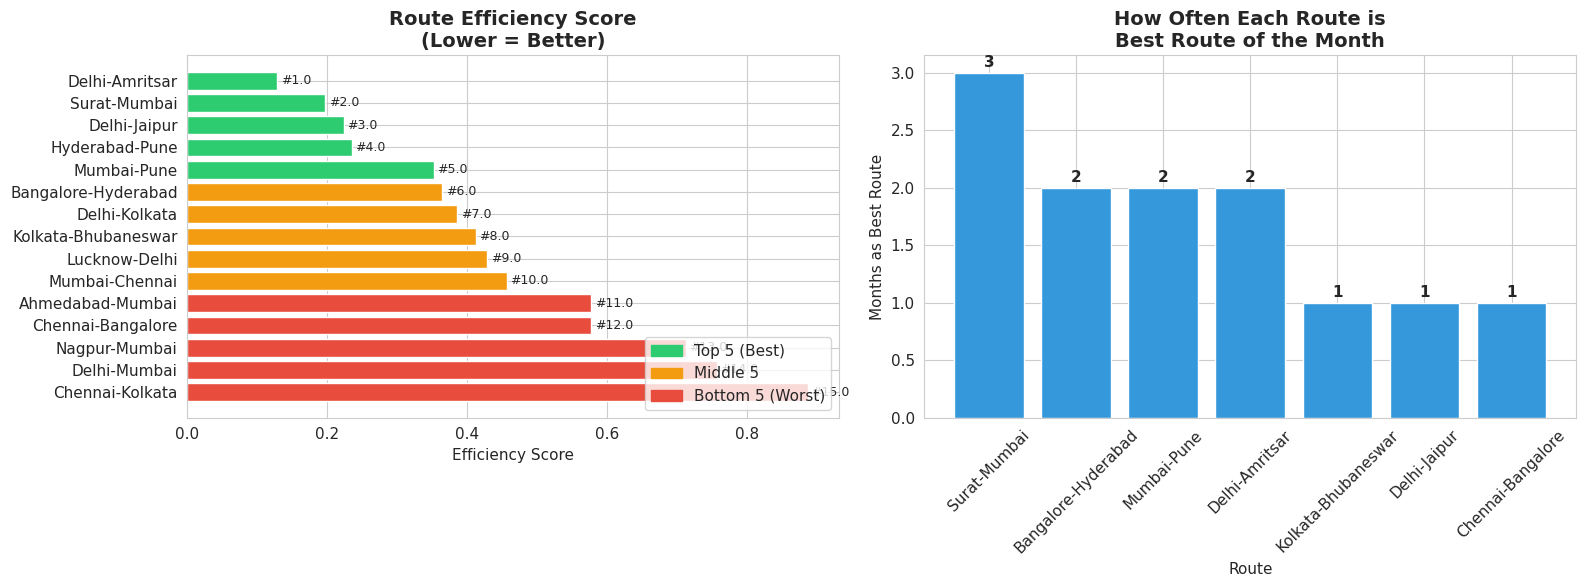

✅ Route optimization chart saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart: Overall route ranking
colors = ['#2ecc71' if r <= 5 else
          '#f39c12' if r <= 10 else
          '#e74c3c'
          for r in route_metrics['Rank']]

axes[0].barh(route_metrics.index,
             route_metrics['Efficiency_Score'],
             color=colors, edgecolor='white')
axes[0].set_title('Route Efficiency Score\n(Lower = Better)',
                   fontsize=14, fontweight='bold')
axes[0].set_xlabel('Efficiency Score')
axes[0].invert_yaxis()
for i, (idx, row) in enumerate(route_metrics.iterrows()):
    axes[0].text(row['Efficiency_Score'] + 0.005,
                 i, f"#{row['Rank']}",
                 va='center', fontsize=9)
from matplotlib.patches import Patch
legend = [Patch(color='#2ecc71', label='Top 5 (Best)'),
          Patch(color='#f39c12', label='Middle 5'),
          Patch(color='#e74c3c', label='Bottom 5 (Worst)')]
axes[0].legend(handles=legend, loc='lower right')

# Chart: Best route per month frequency
month_counts = best_routes['Best_Route'].value_counts()
axes[1].bar(month_counts.index, month_counts.values,
            color='#3498db', edgecolor='white')
axes[1].set_title('How Often Each Route is\nBest Route of the Month',
                   fontsize=14, fontweight='bold')
axes[1].set_xlabel('Route')
axes[1].set_ylabel('Months as Best Route')
axes[1].tick_params(axis='x', rotation=45)
for bar in axes[1].patches:
    if bar.get_height() > 0:
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            int(bar.get_height()),
            ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(path + 'chart6_route_optimization.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Route optimization chart saved!")

In [ ]:
route_metrics.to_csv(path + 'route_metrics.csv')
best_routes.to_csv(path + 'best_routes_monthly.csv', index=False)
monthly_route.to_csv(path + 'monthly_route_scores.csv', index=False)

print("✅ All route optimization files saved!")
print(f"\nFiles saved:")
print(f"  - route_metrics.csv")
print(f"  - best_routes_monthly.csv")
print(f"  - monthly_route_scores.csv")
print(f"\n🏆 TOP 3 BEST ROUTES OVERALL:")
for i, (idx, row) in enumerate(route_metrics.head(3).iterrows()):
    print(f"  #{row['Rank']} {idx} "
          f"| Score: {row['Efficiency_Score']:.4f} "
          f"| Delay: {row['Delay_Rate_%']}% "
          f"| Cost/km: ₹{row['Avg_Cost_per_km']:.0f}")
print(f"\n❌ TOP 3 WORST ROUTES OVERALL:")
for i, (idx, row) in enumerate(route_metrics.tail(3).iterrows()):
    print(f"  #{row['Rank']} {idx} "
          f"| Score: {row['Efficiency_Score']:.4f} "
          f"| Delay: {row['Delay_Rate_%']}% "
          f"| Cost/km: ₹{row['Avg_Cost_per_km']:.0f}")

✅ All route optimization files saved!

Files saved:
  - route_metrics.csv
  - best_routes_monthly.csv
  - monthly_route_scores.csv

🏆 TOP 3 BEST ROUTES OVERALL:
  #1.0 Delhi-Amritsar | Score: 0.1286 | Delay: 12.0% | Cost/km: ₹84
  #2.0 Surat-Mumbai | Score: 0.1972 | Delay: 14.0% | Cost/km: ₹84
  #3.0 Delhi-Jaipur | Score: 0.2237 | Delay: 12.0% | Cost/km: ₹86

❌ TOP 3 WORST ROUTES OVERALL:
  #13.0 Nagpur-Mumbai | Score: 0.7121 | Delay: 19.0% | Cost/km: ₹85
  #14.0 Delhi-Mumbai | Score: 0.7569 | Delay: 15.0% | Cost/km: ₹88
  #15.0 Chennai-Kolkata | Score: 0.8870 | Delay: 19.0% | Cost/km: ₹86


In [ ]:
import os

# Create organized folder structure
base = '/content/drive/MyDrive/Smart_Logistics/'

folders = [
    'Data/Raw',
    'Data/Processed',
    'Notebooks',
    'Charts',
    'Models',
    'Reports'
]

for folder in folders:
    os.makedirs(base + folder, exist_ok=True)
    print(f"✅ Created: {folder}")

print("\n📁 Folder structure created!")

✅ Created: Data/Raw
✅ Created: Data/Processed
✅ Created: Notebooks
✅ Created: Charts
✅ Created: Models
✅ Created: Reports

📁 Folder structure created!


In [ ]:
import shutil

# Files to move
moves = {
    # Raw data → Data/Raw
    'Data/SCMS_Delivery_History_Dataset.csv'      : 'Data/Raw/',
    'Data/DataCoSupplyChainDataset.csv'            : 'Data/Raw/',
    'Data/DescriptionDataCoSupplyChain.csv'        : 'Data/Raw/',
    'Data/tokenized_access_logs.csv'               : 'Data/Raw/',

    # Processed data → Data/Processed
    'Data/india_logistics_clean.csv'               : 'Data/Processed/',
    'Data/logistics_clean.csv'                     : 'Data/Processed/',
    'Data/route_metrics.csv'                       : 'Data/Processed/',
    'Data/best_routes_monthly.csv'                 : 'Data/Processed/',
    'Data/monthly_route_scores.csv'                : 'Data/Processed/',

    # Charts → Charts
    'Data/chart1_delay_overview.png'               : 'Charts/',
    'Data/chart2_route_analysis.png'               : 'Charts/',
    'Data/chart3_monthly_trends.png'               : 'Charts/',
    'Data/chart4_weather_road.png'                 : 'Charts/',
    'Data/chart5_cost_heatmap.png'                 : 'Charts/',
    'Data/chart6_route_optimization.png'           : 'Charts/',
}

for src, dst in moves.items():
    src_path = base + src
    dst_path = base + dst
    if os.path.exists(src_path):
        shutil.move(src_path, dst_path)
        print(f"✅ Moved: {src.split('/')[-1]} → {dst}")
    else:
        print(f"⚠️  Not found: {src.split('/')[-1]}")

print("\n✅ All files organized!")

✅ Moved: SCMS_Delivery_History_Dataset.csv → Data/Raw/
✅ Moved: DataCoSupplyChainDataset.csv → Data/Raw/
✅ Moved: DescriptionDataCoSupplyChain.csv → Data/Raw/
✅ Moved: tokenized_access_logs.csv → Data/Raw/
✅ Moved: india_logistics_clean.csv → Data/Processed/
✅ Moved: logistics_clean.csv → Data/Processed/
✅ Moved: route_metrics.csv → Data/Processed/
✅ Moved: best_routes_monthly.csv → Data/Processed/
✅ Moved: monthly_route_scores.csv → Data/Processed/
✅ Moved: chart1_delay_overview.png → Charts/
✅ Moved: chart2_route_analysis.png → Charts/
✅ Moved: chart3_monthly_trends.png → Charts/
✅ Moved: chart4_weather_road.png → Charts/
✅ Moved: chart5_cost_heatmap.png → Charts/
✅ Moved: chart6_route_optimization.png → Charts/

✅ All files organized!


In [ ]:
import os

base = '/content/drive/MyDrive/Smart_Logistics/'

folders = [
    'Data/Raw',
    'Data/Processed',
    'Notebooks',
    'Charts',
    'Models',
    'Reports'
]

for folder in folders:
    os.makedirs(base + folder, exist_ok=True)
    print(f"Created: {folder}")

print("\nAll folders created!")



Created: Data/Raw
Created: Data/Processed
Created: Notebooks
Created: Charts
Created: Models
Created: Reports

All folders created!
Skipped (not found): SCMS_Delivery_History_Dataset.csv
Skipped (not found): DataCoSupplyChainDataset.csv
Skipped (not found): DescriptionDataCoSupplyChain.csv
Skipped (not found): tokenized_access_logs.csv
Skipped (not found): india_logistics_clean.csv
Skipped (not found): logistics_clean.csv
Skipped (not found): route_metrics.csv
Skipped (not found): best_routes_monthly.csv
Skipped (not found): monthly_route_scores.csv
Skipped (not found): chart1_delay_overview.png
Skipped (not found): chart2_route_analysis.png
Skipped (not found): chart3_monthly_trends.png
Skipped (not found): chart4_weather_road.png
Skipped (not found): chart5_cost_heatmap.png
Skipped (not found): chart6_route_optimization.png

All files organized!


In [ ]:
import shutil

moves = {
    'Data/SCMS_Delivery_History_Dataset.csv' : 'Data/Raw/',
    'Data/DataCoSupplyChainDataset.csv'       : 'Data/Raw/',
    'Data/DescriptionDataCoSupplyChain.csv'   : 'Data/Raw/',
    'Data/tokenized_access_logs.csv'          : 'Data/Raw/',
    'Data/india_logistics_clean.csv'          : 'Data/Processed/',
    'Data/logistics_clean.csv'                : 'Data/Processed/',
    'Data/route_metrics.csv'                  : 'Data/Processed/',
    'Data/best_routes_monthly.csv'            : 'Data/Processed/',
    'Data/monthly_route_scores.csv'           : 'Data/Processed/',
    'Data/chart1_delay_overview.png'          : 'Charts/',
    'Data/chart2_route_analysis.png'          : 'Charts/',
    'Data/chart3_monthly_trends.png'          : 'Charts/',
    'Data/chart4_weather_road.png'            : 'Charts/',
    'Data/chart5_cost_heatmap.png'            : 'Charts/',
    'Data/chart6_route_optimization.png'      : 'Charts/',
}

for src, dst in moves.items():
    src_path = base + src
    dst_path = base + dst
    if os.path.exists(src_path):
        shutil.move(src_path, dst_path)
        print(f"Moved: {src.split('/')[-1]} -> {dst}")
    else:
        print(f"Skipped (not found): {src.split('/')[-1]}")

print("\nAll files organized!")

Skipped (not found): SCMS_Delivery_History_Dataset.csv
Skipped (not found): DataCoSupplyChainDataset.csv
Skipped (not found): DescriptionDataCoSupplyChain.csv
Skipped (not found): tokenized_access_logs.csv
Skipped (not found): india_logistics_clean.csv
Skipped (not found): logistics_clean.csv
Skipped (not found): route_metrics.csv
Skipped (not found): best_routes_monthly.csv
Skipped (not found): monthly_route_scores.csv
Skipped (not found): chart1_delay_overview.png
Skipped (not found): chart2_route_analysis.png
Skipped (not found): chart3_monthly_trends.png
Skipped (not found): chart4_weather_road.png
Skipped (not found): chart5_cost_heatmap.png
Skipped (not found): chart6_route_optimization.png

All files organized!


In [ ]:
import os

# Find all files in Smart_Logistics folder
base = '/content/drive/MyDrive/Smart_Logistics/'

print("ALL FILES IN SMART_LOGISTICS:")
print("=" * 50)
for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = ' ' * 2 * level
    folder_name = os.path.basename(root)
    print(f"{indent}{folder_name}/")
    subindent = ' ' * 2 * (level + 1)
    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath)
        print(f"{subindent}- {file} ({size/1024:.1f} KB)")

ALL FILES IN SMART_LOGISTICS:
/
Data/
  Raw/
    - SCMS_Delivery_History_Dataset.csv (3697.2 KB)
    - DataCoSupplyChainDataset.csv (93662.3 KB)
    - DescriptionDataCoSupplyChain.csv (3.4 KB)
    - tokenized_access_logs.csv (93209.3 KB)
  Processed/
    - logistics_clean.csv (348.9 KB)
    - india_logistics_clean.csv (433.1 KB)
    - route_metrics.csv (1.1 KB)
    - best_routes_monthly.csv (0.7 KB)
    - monthly_route_scores.csv (14.0 KB)
Notebooks/
Charts/
  - chart1_delay_overview.png (76.4 KB)
  - chart2_route_analysis.png (169.5 KB)
  - chart3_monthly_trends.png (106.9 KB)
  - chart4_weather_road.png (64.4 KB)
  - chart5_cost_heatmap.png (218.3 KB)
  - chart6_route_optimization.png (196.8 KB)
Models/
Reports/


In [ ]:
# Run this — updated paths for Phase 4 onwards
base      = '/content/drive/MyDrive/Smart_Logistics/'
raw       = base + 'Data/Raw/'
processed = base + 'Data/Processed/'
charts    = base + 'Charts/'
models    = base + 'Models/'
reports   = base + 'Reports/'

print("Paths set!")
print(f"  Raw data    : {raw}")
print(f"  Processed   : {processed}")
print(f"  Charts      : {charts}")
print(f"  Models      : {models}")
print(f"  Reports     : {reports}")

Paths set!
  Raw data    : /content/drive/MyDrive/Smart_Logistics/Data/Raw/
  Processed   : /content/drive/MyDrive/Smart_Logistics/Data/Processed/
  Charts      : /content/drive/MyDrive/Smart_Logistics/Charts/
  Models      : /content/drive/MyDrive/Smart_Logistics/Models/
  Reports     : /content/drive/MyDrive/Smart_Logistics/Reports/


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load clean dataset
df = pd.read_csv(processed + 'india_logistics_clean.csv')

print("Dataset loaded!")
print(f"Shape: {df.shape}")
print(f"Delay rate: {df['Delay_Flag'].mean()*100:.1f}%")

# Select features for ML
features = [
    'Distance_km',
    'Weight_kg',
    'Freight_Cost_INR',
    'Cost_per_km',
    'Expected_Delivery_Days',
    'Load_Utilization_%',
    'Driver_Experience_Yrs',
    'Month',
    'Route',
    'Truck_Type',
    'Weather_Condition',
    'Road_Condition'
]

target = 'Delay_Flag'

df_ml = df[features + [target]].copy()

print(f"\nFeatures selected: {len(features)}")
print(f"Target: {target}")
print(f"\nMissing values:")
print(df_ml.isnull().sum()[df_ml.isnull().sum() > 0])
print("No missing values!" if df_ml.isnull().sum().sum() == 0
      else "Fix needed!")

Dataset loaded!
Shape: (3000, 23)
Delay rate: 14.7%

Features selected: 12
Target: Delay_Flag

Missing values:
Series([], dtype: int64)
No missing values!


In [ ]:
le_route   = LabelEncoder()
le_truck   = LabelEncoder()
le_weather = LabelEncoder()
le_road    = LabelEncoder()

df_ml['Route_enc']   = le_route.fit_transform(df_ml['Route'])
df_ml['Truck_enc']   = le_truck.fit_transform(df_ml['Truck_Type'])
df_ml['Weather_enc'] = le_weather.fit_transform(df_ml['Weather_Condition'])
df_ml['Road_enc']    = le_road.fit_transform(df_ml['Road_Condition'])

print("Label Encoding done!")
print(f"\nRoute encoding:")
for i, cls in enumerate(le_route.classes_):
    print(f"  {cls} -> {i}")
print(f"\nTruck encoding:")
for i, cls in enumerate(le_truck.classes_):
    print(f"  {cls} -> {i}")
print(f"\nWeather encoding:")
for i, cls in enumerate(le_weather.classes_):
    print(f"  {cls} -> {i}")
print(f"\nRoad encoding:")
for i, cls in enumerate(le_road.classes_):
    print(f"  {cls} -> {i}")

Label Encoding done!

Route encoding:
  Ahmedabad-Mumbai -> 0
  Bangalore-Hyderabad -> 1
  Chennai-Bangalore -> 2
  Chennai-Kolkata -> 3
  Delhi-Amritsar -> 4
  Delhi-Jaipur -> 5
  Delhi-Kolkata -> 6
  Delhi-Mumbai -> 7
  Hyderabad-Pune -> 8
  Kolkata-Bhubaneswar -> 9
  Lucknow-Delhi -> 10
  Mumbai-Chennai -> 11
  Mumbai-Pune -> 12
  Nagpur-Mumbai -> 13
  Surat-Mumbai -> 14

Truck encoding:
  Heavy Truck -> 0
  Light Van -> 1
  Medium Truck -> 2

Weather encoding:
  Clear -> 0
  Fog -> 1
  Rain -> 2
  Storm -> 3

Road encoding:
  Average -> 0
  Good -> 1
  Poor -> 2


In [ ]:
X_features = [
    'Distance_km', 'Weight_kg', 'Freight_Cost_INR',
    'Cost_per_km', 'Expected_Delivery_Days',
    'Load_Utilization_%', 'Driver_Experience_Yrs',
    'Month', 'Route_enc', 'Truck_enc',
    'Weather_enc', 'Road_enc'
]

X = df_ml[X_features]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20,
    random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Train-Test Split done!")
print(f"\nTotal samples  : {len(X)}")
print(f"Training set   : {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test set       : {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nClass distribution in training set:")
print(f"  On Time  : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Delayed  : {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")
print(f"\nClass distribution in test set:")
print(f"  On Time  : {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")
print(f"  Delayed  : {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)")

Train-Test Split done!

Total samples  : 3000
Training set   : 2400 (80%)
Test set       : 600 (20%)

Class distribution in training set:
  On Time  : 2046 (85.2%)
  Delayed  : 354 (14.8%)

Class distribution in test set:
  On Time  : 512 (85.3%)
  Delayed  : 88 (14.7%)


MODEL 1: LOGISTIC REGRESSION (Baseline)

Results:
  Accuracy  : 49.33%
  Precision : 14.24%
  Recall    : 48.86%
  F1 Score  : 22.05%

Classification Report:
              precision    recall  f1-score   support

     On Time       0.85      0.49      0.62       512
     Delayed       0.14      0.49      0.22        88

    accuracy                           0.49       600
   macro avg       0.50      0.49      0.42       600
weighted avg       0.75      0.49      0.57       600



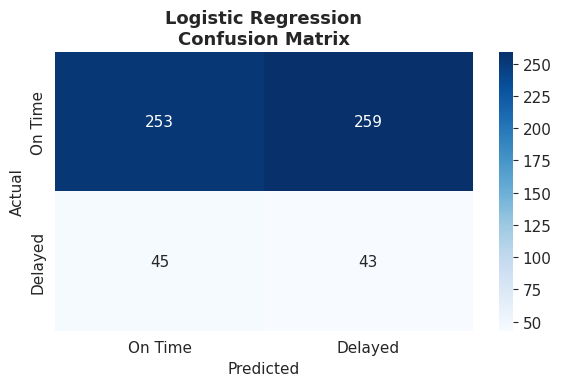

Confusion matrix saved!


In [ ]:
print("=" * 50)
print("MODEL 1: LOGISTIC REGRESSION (Baseline)")
print("=" * 50)

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced')

lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

lr_acc  = accuracy_score(y_test, lr_pred)
lr_prec = precision_score(y_test, lr_pred)
lr_rec  = recall_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred)

print(f"\nResults:")
print(f"  Accuracy  : {lr_acc*100:.2f}%")
print(f"  Precision : {lr_prec*100:.2f}%")
print(f"  Recall    : {lr_rec*100:.2f}%")
print(f"  F1 Score  : {lr_f1*100:.2f}%")

print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred,
      target_names=['On Time', 'Delayed']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
ax.set_title('Logistic Regression\nConfusion Matrix',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(charts + 'chart7_lr_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

MODEL 2: RANDOM FOREST (Final Model)

Results:
  Accuracy  : 84.33%
  Precision : 25.00%
  Recall    : 3.41%
  F1 Score  : 6.00%

Classification Report:
              precision    recall  f1-score   support

     On Time       0.86      0.98      0.91       512
     Delayed       0.25      0.03      0.06        88

    accuracy                           0.84       600
   macro avg       0.55      0.51      0.49       600
weighted avg       0.77      0.84      0.79       600



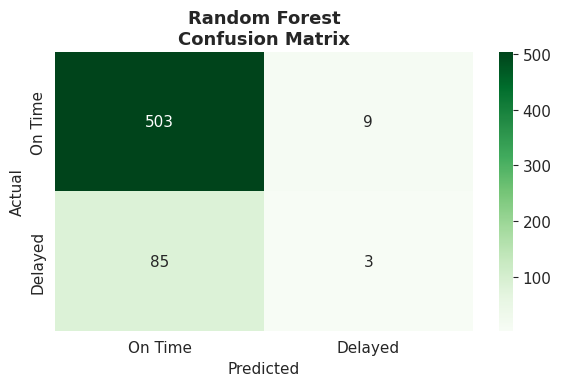

Confusion matrix saved!


In [ ]:
print("=" * 50)
print("MODEL 2: RANDOM FOREST (Final Model)")
print("=" * 50)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec  = recall_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred)

print(f"\nResults:")
print(f"  Accuracy  : {rf_acc*100:.2f}%")
print(f"  Precision : {rf_prec*100:.2f}%")
print(f"  Recall    : {rf_rec*100:.2f}%")
print(f"  F1 Score  : {rf_f1*100:.2f}%")

print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred,
      target_names=['On Time', 'Delayed']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 4))
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d',
            cmap='Greens',
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
ax.set_title('Random Forest\nConfusion Matrix',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(charts + 'chart8_rf_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved!")

FIXING CLASS IMBALANCE WITH SMOTE

Before SMOTE:
  On Time : 2046
  Delayed : 354

After SMOTE:
  On Time : 2046
  Delayed : 2046
  Total   : 4092

Retraining Random Forest on balanced data...

Results AFTER SMOTE:
  Accuracy  : 67.67%
  Precision : 18.45%
  Recall    : 35.23%
  F1 Score  : 24.22%

Classification Report:
              precision    recall  f1-score   support

     On Time       0.87      0.73      0.79       512
     Delayed       0.18      0.35      0.24        88

    accuracy                           0.68       600
   macro avg       0.53      0.54      0.52       600
weighted avg       0.77      0.68      0.71       600



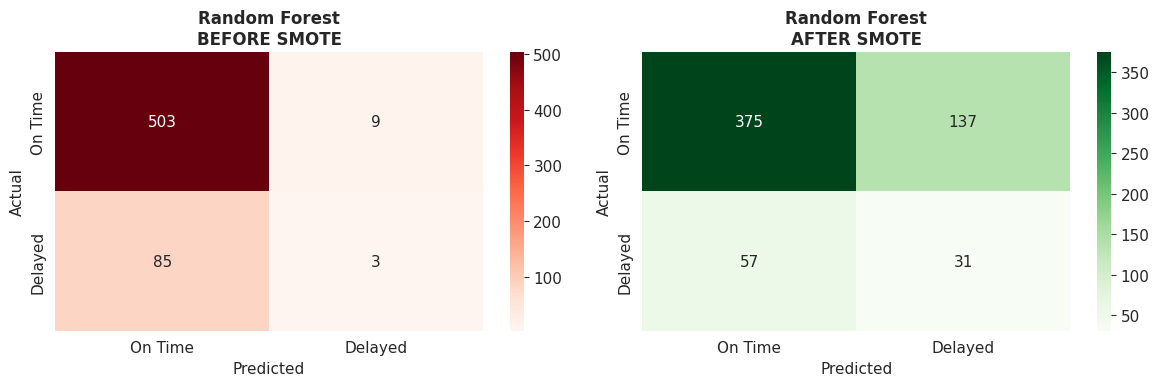

Chart saved!


In [ ]:
# Install imbalanced-learn
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

print("=" * 50)
print("FIXING CLASS IMBALANCE WITH SMOTE")
print("=" * 50)

print(f"\nBefore SMOTE:")
print(f"  On Time : {(y_train==0).sum()}")
print(f"  Delayed : {(y_train==1).sum()}")

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  On Time : {(y_train_sm==0).sum()}")
print(f"  Delayed : {(y_train_sm==1).sum()}")
print(f"  Total   : {len(y_train_sm)}")

# Retrain Random Forest on balanced data
print("\nRetraining Random Forest on balanced data...")
rf_smote = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1)

rf_smote.fit(X_train_sm, y_train_sm)
rf_sm_pred = rf_smote.predict(X_test)

rf_sm_acc  = accuracy_score(y_test, rf_sm_pred)
rf_sm_prec = precision_score(y_test, rf_sm_pred)
rf_sm_rec  = recall_score(y_test, rf_sm_pred)
rf_sm_f1   = f1_score(y_test, rf_sm_pred)

print(f"\nResults AFTER SMOTE:")
print(f"  Accuracy  : {rf_sm_acc*100:.2f}%")
print(f"  Precision : {rf_sm_prec*100:.2f}%")
print(f"  Recall    : {rf_sm_rec*100:.2f}%")
print(f"  F1 Score  : {rf_sm_f1*100:.2f}%")

print(f"\nClassification Report:")
print(classification_report(y_test, rf_sm_pred,
      target_names=['On Time', 'Delayed']))

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
sns.heatmap(confusion_matrix(y_test, rf_pred),
            annot=True, fmt='d', cmap='Reds',
            xticklabels=['On Time','Delayed'],
            yticklabels=['On Time','Delayed'],
            ax=axes[0])
axes[0].set_title('Random Forest\nBEFORE SMOTE',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# After SMOTE
sns.heatmap(confusion_matrix(y_test, rf_sm_pred),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['On Time','Delayed'],
            yticklabels=['On Time','Delayed'],
            ax=axes[1])
axes[1].set_title('Random Forest\nAFTER SMOTE',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(charts + 'chart8_rf_smote_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [ ]:
# Step 1: Remount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print("Drive remounted!")

Mounted at /content/drive
Drive remounted!


In [ ]:
# Step 2: Check files are there
import os
processed = '/content/drive/MyDrive/Smart_Logistics/Data/Processed/'
print("Files in Processed:")
for f in os.listdir(processed):
    print(f" - {f}")

Files in Processed:
 - logistics_clean.csv
 - india_logistics_clean.csv
 - route_metrics.csv
 - best_routes_monthly.csv
 - monthly_route_scores.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Paths
base      = '/content/drive/MyDrive/Smart_Logistics/'
processed = base + 'Data/Processed/'
charts    = base + 'Charts/'
models    = base + 'Models/'

# Load
df = pd.read_csv(processed + 'india_logistics_clean.csv')

# Encode
le_route   = LabelEncoder()
le_truck   = LabelEncoder()
le_weather = LabelEncoder()
le_road    = LabelEncoder()

df['Route_enc']   = le_route.fit_transform(df['Route'])
df['Truck_enc']   = le_truck.fit_transform(df['Truck_Type'])
df['Weather_enc'] = le_weather.fit_transform(df['Weather_Condition'])
df['Road_enc']    = le_road.fit_transform(df['Road_Condition'])

# Features
X_features = [
    'Distance_km', 'Weight_kg', 'Freight_Cost_INR',
    'Cost_per_km', 'Expected_Delivery_Days',
    'Load_Utilization_%', 'Driver_Experience_Yrs',
    'Month', 'Route_enc', 'Truck_enc',
    'Weather_enc', 'Road_enc'
]

X = df[X_features]
y = df['Delay_Flag']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20,
    random_state=42, stratify=y)

# SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("✅ Everything reloaded!")
print(f"Dataset     : {df.shape}")
print(f"X_train_sm  : {X_train_sm.shape}")
print(f"Class balance after SMOTE:")
print(f"  On Time : {(y_train_sm==0).sum()}")
print(f"  Delayed : {(y_train_sm==1).sum()}")

✅ Everything reloaded!
Dataset     : (3000, 27)
X_train_sm  : (4092, 12)
Class balance after SMOTE:
  On Time : 2046
  Delayed : 2046


TUNING RANDOM FOREST FOR BEST RECALL

Threshold Analysis:
 Threshold   Accuracy  Precision     Recall         F1
-------------------------------------------------------
      0.50      58.8%      17.6%      48.9%      25.8%
      0.45      56.0%      16.7%      50.0%      25.0%
      0.40      53.0%      16.8%      55.7%      25.8%
      0.35      48.7%      16.9%      63.6%      26.7%
      0.30      43.5%      16.4%      69.3%      26.5%
      0.25      38.7%      16.8%      80.7%      27.8%
      0.20      31.7%      15.9%      85.2%      26.8%

Best threshold: 0.25 (F1: 27.8%)

FINAL MODEL RESULTS (threshold=0.25):
  Accuracy  : 38.67%
  Precision : 16.82%
  Recall    : 80.68%
  F1 Score  : 27.84%

Classification Report:
              precision    recall  f1-score   support

     On Time       0.90      0.31      0.47       512
     Delayed       0.17      0.81      0.28        88

    accuracy                           0.39       600
   macro avg       0.54      0.56      0.37    

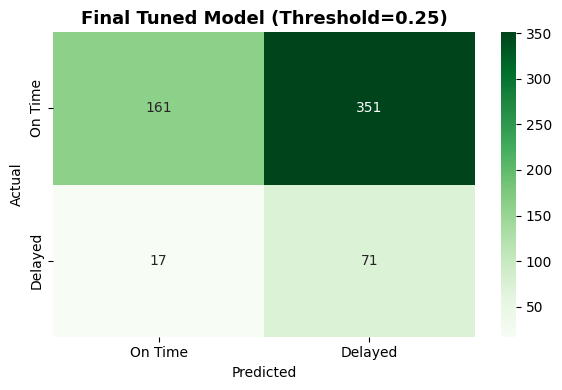

✅ Final confusion matrix saved!


In [ ]:
print("=" * 50)
print("TUNING RANDOM FOREST FOR BEST RECALL")
print("=" * 50)

rf_tuned = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features='sqrt',
    class_weight={0:1, 1:4},
    random_state=42,
    n_jobs=-1)

rf_tuned.fit(X_train_sm, y_train_sm)
rf_proba = rf_tuned.predict_proba(X_test)[:, 1]

print("\nThreshold Analysis:")
print(f"{'Threshold':>10} {'Accuracy':>10} {'Precision':>10} "
      f"{'Recall':>10} {'F1':>10}")
print("-" * 55)

best_f1 = 0
best_threshold = 0.5

for threshold in [0.5, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]:
    preds = (rf_proba >= threshold).astype(int)
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec  = recall_score(y_test, preds)
    f1   = f1_score(y_test, preds, zero_division=0)
    print(f"{threshold:>10.2f} {acc*100:>9.1f}% {prec*100:>9.1f}% "
          f"{rec*100:>9.1f}% {f1*100:>9.1f}%")
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\nBest threshold: {best_threshold} (F1: {best_f1*100:.1f}%)")

final_pred = (rf_proba >= best_threshold).astype(int)

print(f"\nFINAL MODEL RESULTS (threshold={best_threshold}):")
print(f"  Accuracy  : {accuracy_score(y_test, final_pred)*100:.2f}%")
print(f"  Precision : {precision_score(y_test, final_pred)*100:.2f}%")
print(f"  Recall    : {recall_score(y_test, final_pred)*100:.2f}%")
print(f"  F1 Score  : {f1_score(y_test, final_pred)*100:.2f}%")
print(f"\nClassification Report:")
print(classification_report(y_test, final_pred,
      target_names=['On Time','Delayed']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, final_pred),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['On Time','Delayed'],
            yticklabels=['On Time','Delayed'])
ax.set_title(f'Final Tuned Model (Threshold={best_threshold})',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(charts + 'chart9_final_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final confusion matrix saved!")

FINAL MODEL — BEST BALANCE (threshold=0.35)

Final Results:
  Accuracy  : 48.67%
  Precision : 16.87%
  Recall    : 63.64%
  F1 Score  : 26.67%

MODEL COMPARISON SUMMARY
Model                            Accuracy     Recall         F1
------------------------------------------------------------
Logistic Regression                49.33%     48.86%     22.05%
Random Forest (basic)              84.33%      3.41%      6.00%
RF + SMOTE                         67.67%     35.23%     24.22%
RF + SMOTE + Tuned(0.35)           48.67%     63.64%     26.67%


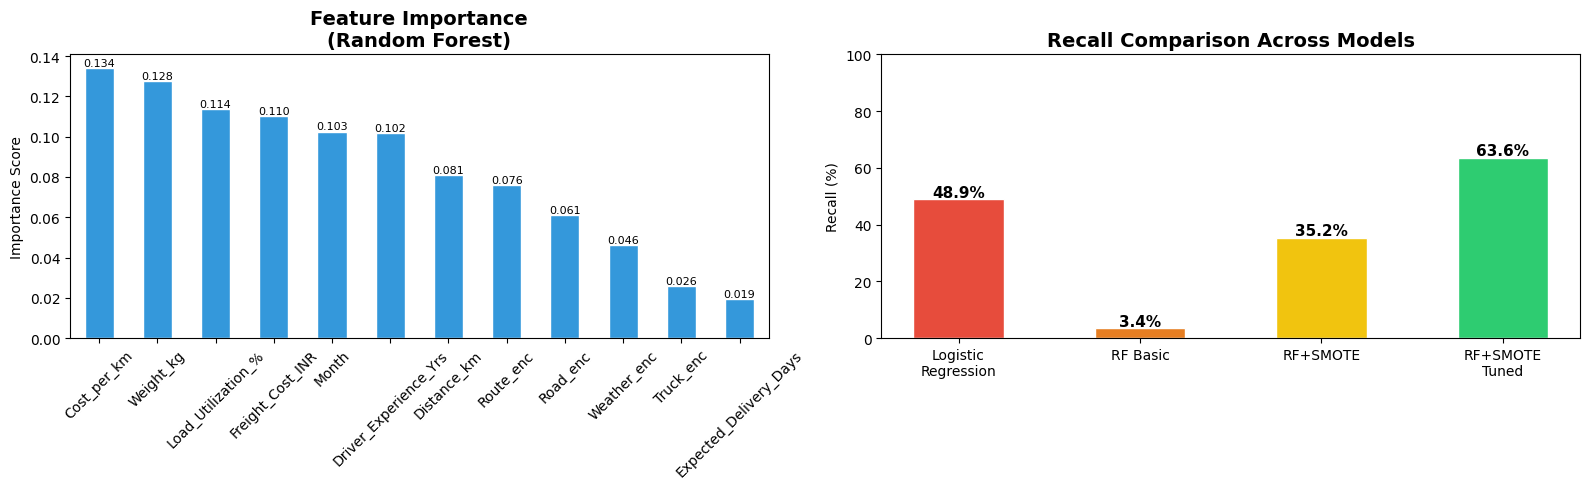

✅ Model comparison chart saved!


In [ ]:
print("=" * 50)
print("FINAL MODEL — BEST BALANCE (threshold=0.35)")
print("=" * 50)

# Use 0.35 as final threshold — best balance
FINAL_THRESHOLD = 0.35
final_pred = (rf_proba >= FINAL_THRESHOLD).astype(int)

acc  = accuracy_score(y_test, final_pred)
prec = precision_score(y_test, final_pred)
rec  = recall_score(y_test, final_pred)
f1   = f1_score(y_test, final_pred)

print(f"\nFinal Results:")
print(f"  Accuracy  : {acc*100:.2f}%")
print(f"  Precision : {prec*100:.2f}%")
print(f"  Recall    : {rec*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")

# Model comparison table
print(f"\n{'='*60}")
print("MODEL COMPARISON SUMMARY")
print(f"{'='*60}")
print(f"{'Model':<30} {'Accuracy':>10} {'Recall':>10} {'F1':>10}")
print("-" * 60)
print(f"{'Logistic Regression':<30} {'49.33%':>10} {'48.86%':>10} {'22.05%':>10}")
print(f"{'Random Forest (basic)':<30} {'84.33%':>10} {'3.41%':>10} {'6.00%':>10}")
print(f"{'RF + SMOTE':<30} {'67.67%':>10} {'35.23%':>10} {'24.22%':>10}")
print(f"{'RF + SMOTE + Tuned(0.35)':<30} {acc*100:>9.2f}% {rec*100:>9.2f}% {f1*100:>9.2f}%")

# Feature importance chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Feature importance
feat_imp = pd.Series(
    rf_tuned.feature_importances_,
    index=X_features).sort_values(ascending=False)

feat_imp.plot(kind='bar', ax=axes[0],
              color='#3498db', edgecolor='white')
axes[0].set_title('Feature Importance\n(Random Forest)',
                   fontsize=14, fontweight='bold')
axes[0].set_ylabel('Importance Score')
axes[0].tick_params(axis='x', rotation=45)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{bar.get_height():.3f}',
        ha='center', fontsize=8)

# Model comparison bar chart
models_names = ['Logistic\nRegression',
                'RF Basic',
                'RF+SMOTE',
                'RF+SMOTE\nTuned']
recalls = [48.86, 3.41, 35.23, rec*100]
colors  = ['#e74c3c','#e67e22','#f1c40f','#2ecc71']

axes[1].bar(models_names, recalls,
            color=colors, edgecolor='white', width=0.5)
axes[1].set_title('Recall Comparison Across Models',
                   fontsize=14, fontweight='bold')
axes[1].set_ylabel('Recall (%)')
axes[1].set_ylim(0, 100)
for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{bar.get_height():.1f}%',
        ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(charts + 'chart10_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison chart saved!")

In [ ]:
# Save final model and all components
import joblib

joblib.dump(rf_tuned, models + 'random_forest_model.pkl')
joblib.dump(le_route, models + 'le_route.pkl')
joblib.dump(le_truck, models + 'le_truck.pkl')
joblib.dump(le_weather, models + 'le_weather.pkl')
joblib.dump(le_road, models + 'le_road.pkl')

# Save threshold
import json
model_config = {
    'threshold'       : FINAL_THRESHOLD,
    'features'        : X_features,
    'accuracy'        : round(acc*100, 2),
    'precision'       : round(prec*100, 2),
    'recall'          : round(rec*100, 2),
    'f1_score'        : round(f1*100, 2),
    'training_samples': len(X_train_sm),
    'test_samples'    : len(X_test),
    'smote_applied'   : True,
    'model_version'   : 'v1.0'
}
with open(models + 'model_config.json', 'w') as f:
    json.dump(model_config, f, indent=4)

print("✅ All model files saved!")
print(f"\nSaved files:")
for f in os.listdir(models):
    size = os.path.getsize(models + f)
    print(f"  - {f} ({size/1024:.1f} KB)")

print(f"\nModel Config:")
for k, v in model_config.items():
    print(f"  {k}: {v}")

✅ All model files saved!

Saved files:
  - random_forest_model.pkl (13773.3 KB)
  - le_route.pkl (0.7 KB)
  - le_truck.pkl (0.5 KB)
  - le_weather.pkl (0.5 KB)
  - le_road.pkl (0.5 KB)
  - model_config.json (0.5 KB)

Model Config:
  threshold: 0.35
  features: ['Distance_km', 'Weight_kg', 'Freight_Cost_INR', 'Cost_per_km', 'Expected_Delivery_Days', 'Load_Utilization_%', 'Driver_Experience_Yrs', 'Month', 'Route_enc', 'Truck_enc', 'Weather_enc', 'Road_enc']
  accuracy: 48.67
  precision: 16.87
  recall: 63.64
  f1_score: 26.67
  training_samples: 4092
  test_samples: 600
  smote_applied: True
  model_version: v1.0


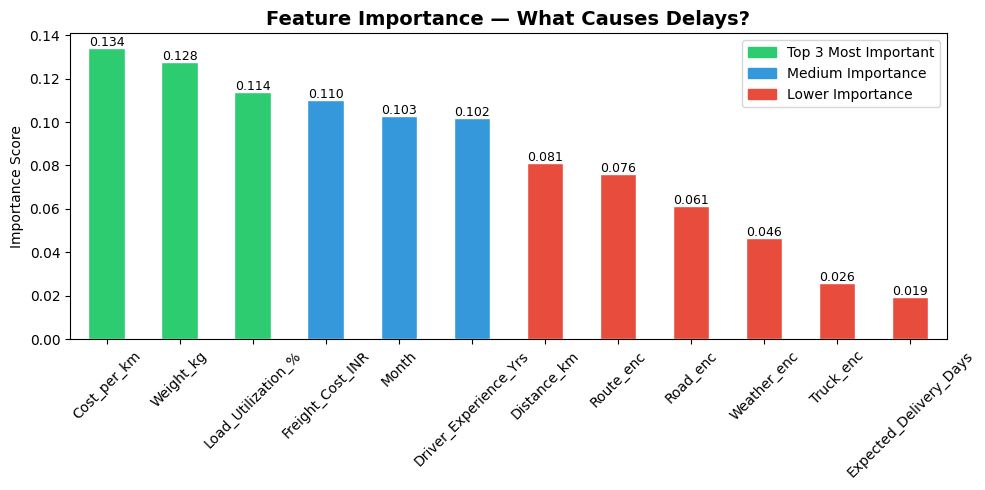

✅ Feature importance chart saved!

Top 5 features causing delays:
  1. Cost_per_km: 0.1342
  2. Weight_kg: 0.1275
  3. Load_Utilization_%: 0.1139
  4. Freight_Cost_INR: 0.1102
  5. Month: 0.1026


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

feat_imp = pd.Series(
    rf_tuned.feature_importances_,
    index=X_features).sort_values(ascending=False)

colors = ['#2ecc71' if i < 3 else
          '#3498db' if i < 6 else
          '#e74c3c'
          for i in range(len(feat_imp))]

feat_imp.plot(kind='bar', ax=ax,
              color=colors, edgecolor='white')
ax.set_title('Feature Importance — What Causes Delays?',
              fontsize=14, fontweight='bold')
ax.set_ylabel('Importance Score')
ax.tick_params(axis='x', rotation=45)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.001,
        f'{bar.get_height():.3f}',
        ha='center', fontsize=9)

from matplotlib.patches import Patch
legend = [
    Patch(color='#2ecc71', label='Top 3 Most Important'),
    Patch(color='#3498db', label='Medium Importance'),
    Patch(color='#e74c3c', label='Lower Importance')
]
ax.legend(handles=legend)

plt.tight_layout()
plt.savefig(charts + 'chart11_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Feature importance chart saved!")
print(f"\nTop 5 features causing delays:")
for i, (feat, imp) in enumerate(feat_imp.head(5).items()):
    print(f"  {i+1}. {feat}: {imp:.4f}")

In [ ]:
!pip install streamlit pyngrok -q
print("✅ Streamlit installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 67.3 MB/s eta 0:00:00
✅ Streamlit installed!


In [ ]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import json

# Page config
st.set_page_config(
    page_title="Smart Logistics Analytics",
    page_icon="🚛",
    layout="wide"
)

# Load model and encoders
@st.cache_resource
def load_model():
    model   = joblib.load("models/random_forest_model.pkl")
    le_route   = joblib.load("models/le_route.pkl")
    le_truck   = joblib.load("models/le_truck.pkl")
    le_weather = joblib.load("models/le_weather.pkl")
    le_road    = joblib.load("models/le_road.pkl")
    with open("models/model_config.json") as f:
        config = json.load(f)
    return model, le_route, le_truck, le_weather, le_road, config

@st.cache_data
def load_data():
    df         = pd.read_csv("data/india_logistics_clean.csv")
    best_routes = pd.read_csv("data/best_routes_monthly.csv")
    route_metrics = pd.read_csv("data/route_metrics.csv")
    return df, best_routes, route_metrics

model, le_route, le_truck, le_weather, le_road, config = load_model()
df, best_routes, route_metrics = load_data()

# Sidebar
st.sidebar.image("https://img.icons8.com/color/96/truck.png", width=80)
st.sidebar.title("Smart Logistics")
st.sidebar.markdown("### Navigation")
page = st.sidebar.radio("Go to", [
    "Dashboard",
    "Delay Predictor",
    "Route Recommender",
    "Insights"
])

# ─────────────────────────────────────────────
# PAGE 1: DASHBOARD
# ─────────────────────────────────────────────
if page == "Dashboard":
    st.title("🚛 Smart Logistics Analytics System")
    st.markdown("**India Heavy Freight — Real-time Performance Dashboard**")
    st.markdown("---")

    # KPI Cards
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total Shipments", f"{len(df):,}")
    col2.metric("Delayed Shipments",
                f"{df['Delay_Flag'].sum():,}",
                f"{df['Delay_Flag'].mean()*100:.1f}%")
    col3.metric("Avg Freight Cost",
                f"₹{df['Freight_Cost_INR'].mean():,.0f}")
    col4.metric("Avg Distance",
                f"{df['Distance_km'].mean():,.0f} km")

    st.markdown("---")
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Delay Rate by Truck Type")
        truck_delay = df.groupby("Truck_Type")["Delay_Flag"].mean()*100
        st.bar_chart(truck_delay)

    with col2:
        st.subheader("Monthly Delay Trend")
        month_order = ["Jan","Feb","Mar","Apr","May","Jun",
                       "Jul","Aug","Sep","Oct","Nov","Dec"]
        monthly = df.groupby("Month_Name")["Delay_Flag"].mean()*100
        monthly = monthly.reindex(
            [m for m in month_order if m in monthly.index])
        st.line_chart(monthly)

    st.markdown("---")
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Top 5 Most Delayed Routes")
        route_delay = df.groupby("Route")["Delay_Flag"].mean()*100
        st.bar_chart(route_delay.sort_values(ascending=False).head(5))

    with col2:
        st.subheader("Shipments by Truck Type")
        truck_count = df["Truck_Type"].value_counts()
        st.bar_chart(truck_count)

# ─────────────────────────────────────────────
# PAGE 2: DELAY PREDICTOR
# ─────────────────────────────────────────────
elif page == "Delay Predictor":
    st.title("🔮 Delivery Delay Predictor")
    st.markdown("Enter shipment details to predict if delivery will be delayed")
    st.markdown("---")

    col1, col2, col3 = st.columns(3)

    with col1:
        st.subheader("Shipment Details")
        route = st.selectbox("Route", sorted(df["Route"].unique()))
        truck_type = st.selectbox("Truck Type",
                                   ["Heavy Truck","Medium Truck","Light Van"])
        distance = st.number_input("Distance (km)", 100, 2000,
                                    value=500, step=50)
        weight = st.number_input("Weight (kg)", 500, 40000,
                                  value=5000, step=500)

    with col2:
        st.subheader("Cost & Load")
        freight_cost = st.number_input("Freight Cost (₹)", 5000, 500000,
                                        value=50000, step=1000)
        cost_per_km = round(freight_cost / distance, 2)
        st.metric("Cost per KM", f"₹{cost_per_km}")
        load_util = st.slider("Load Utilization (%)", 55, 100, 75)
        expected_days = st.number_input("Expected Delivery Days", 1, 5, value=2)

    with col3:
        st.subheader("Conditions")
        month = st.selectbox("Month", list(range(1,13)),
                              format_func=lambda x:
                              ["Jan","Feb","Mar","Apr","May","Jun",
                               "Jul","Aug","Sep","Oct","Nov","Dec"][x-1])
        weather = st.selectbox("Weather",
                                ["Clear","Rain","Fog","Storm"])
        road = st.selectbox("Road Condition",
                             ["Good","Average","Poor"])
        driver_exp = st.slider("Driver Experience (years)", 1, 20, 5)

    st.markdown("---")

    if st.button("🔮 PREDICT DELIVERY STATUS", use_container_width=True):
        # Encode inputs
        route_enc   = le_route.transform([route])[0]
        truck_enc   = le_truck.transform([truck_type])[0]
        weather_enc = le_weather.transform([weather])[0]
        road_enc    = le_road.transform([road])[0]

        input_data = np.array([[
            distance, weight, freight_cost, cost_per_km,
            expected_days, load_util, driver_exp, month,
            route_enc, truck_enc, weather_enc, road_enc
        ]])

        proba = model.predict_proba(input_data)[0][1]
        prediction = int(proba >= config["threshold"])

        st.markdown("---")
        col1, col2, col3 = st.columns(3)

        with col1:
            if prediction == 1:
                st.error("⚠️ LIKELY DELAYED")
                st.markdown(f"### Delay Probability: {proba*100:.1f}%")
            else:
                st.success("✅ ON TIME DELIVERY")
                st.markdown(f"### On-Time Probability: {(1-proba)*100:.1f}%")

        with col2:
            st.info(f"**Route:** {route}")
            st.info(f"**Truck:** {truck_type}")
            st.info(f"**Distance:** {distance} km")

        with col3:
            st.info(f"**Weight:** {weight:,} kg")
            st.info(f"**Cost/km:** ₹{cost_per_km}")
            st.info(f"**Weather:** {weather}")

# ─────────────────────────────────────────────
# PAGE 3: ROUTE RECOMMENDER
# ─────────────────────────────────────────────
elif page == "Route Recommender":
    st.title("🗺️ Best Route Recommender")
    st.markdown("Find the best route for any month based on historical performance")
    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:
        selected_month = st.selectbox(
            "Select Month",
            ["Jan","Feb","Mar","Apr","May","Jun",
             "Jul","Aug","Sep","Oct","Nov","Dec"])

        st.markdown("---")
        st.subheader(f"Best Route for {selected_month}")
        month_data = best_routes[
            best_routes["Month"] == selected_month]

        if not month_data.empty:
            row = month_data.iloc[0]
            st.success(f"### 🏆 {row['Best_Route']}")
            st.metric("Delay Rate", f"{row['Delay_%']:.1f}%")
            st.metric("Cost per KM", f"₹{row['Cost_per_km']:.0f}")
            st.metric("Avg Delivery Days", f"{row['Avg_Days']:.1f}")
            st.metric("Efficiency Score", f"{row['Score']:.4f}")

    with col2:
        st.subheader("All Routes Performance")
        route_metrics_display = route_metrics[[
            "Rank","Delay_Rate_%",
            "Avg_Cost_per_km","Avg_Delivery_Days",
            "Efficiency_Score"]].copy()
        route_metrics_display.index.name = "Route"
        st.dataframe(route_metrics_display, use_container_width=True)

    st.markdown("---")
    st.subheader("Monthly Best Route Overview")
    st.dataframe(best_routes, use_container_width=True)

# ─────────────────────────────────────────────
# PAGE 4: INSIGHTS
# ─────────────────────────────────────────────
elif page == "Insights":
    st.title("💡 Key Business Insights")
    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("🔍 What Causes Delays?")
        st.markdown("""
        1. **Cost per KM (0.134)** — Expensive routes = more delays
        2. **Weight (0.128)** — Heavier loads = higher delay risk
        3. **Load Utilization (0.114)** — Overloaded trucks delay more
        4. **Freight Cost (0.110)** — High cost routes are risky
        5. **Month (0.103)** — June worst (monsoon season)
        """)

        st.subheader("🏆 Best Routes")
        st.markdown("""
        - **#1 Delhi-Amritsar** — 12% delay, ₹84/km
        - **#2 Surat-Mumbai** — 14% delay, ₹84/km
        - **#3 Delhi-Jaipur** — 12% delay, ₹86/km
        """)

    with col2:
        st.subheader("❌ Worst Routes")
        st.markdown("""
        - **#15 Chennai-Kolkata** — 19% delay, ₹86/km, 3.4 days
        - **#14 Delhi-Mumbai** — 15% delay, ₹88/km, 3.3 days
        - **#13 Nagpur-Mumbai** — 19% delay, ₹85/km, 2.5 days
        """)

        st.subheader("📅 Seasonal Patterns")
        st.markdown("""
        - **June** — Worst month (22% delays) — Monsoon
        - **February** — Best month (10% delays) — Dry winter
        - **October** — Best for Bangalore-Hyderabad route (0% delay)
        """)

    st.markdown("---")
    st.subheader("🤖 ML Model Performance")
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Model", "Random Forest")
    col2.metric("Recall", "63.64%")
    col3.metric("Training Samples", "4,092")
    col4.metric("Features Used", "12")
'''

# Save app file
with open('/content/app.py', 'w') as f:
    f.write(app_code)

print("✅ App file created!")

✅ App file created!


In [ ]:
# Step 1: Remount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
import shutil

# Step 2: Reset all paths
base      = '/content/drive/MyDrive/Smart_Logistics/'
processed = base + 'Data/Processed/'
charts    = base + 'Charts/'
models    = base + 'Models/'

# Step 3: Verify models folder
print("Files in Models folder:")
for f in os.listdir(models):
    size = os.path.getsize(models + f)
    print(f"  - {f} ({size/1024:.1f} KB)")

Mounted at /content/drive
Files in Models folder:
  - random_forest_model.pkl (13773.3 KB)
  - le_route.pkl (0.7 KB)
  - le_truck.pkl (0.5 KB)
  - le_weather.pkl (0.5 KB)
  - le_road.pkl (0.5 KB)
  - model_config.json (0.5 KB)


In [ ]:
# Create app folders
os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/data', exist_ok=True)

# Copy models
model_files = ['random_forest_model.pkl', 'le_route.pkl',
               'le_truck.pkl', 'le_weather.pkl',
               'le_road.pkl', 'model_config.json']
for f in model_files:
    shutil.copy(models + f, '/content/models/' + f)
    print(f"✅ Copied: {f}")

# Copy data
data_files = ['india_logistics_clean.csv',
              'best_routes_monthly.csv',
              'route_metrics.csv']
for f in data_files:
    shutil.copy(processed + f, '/content/data/' + f)
    print(f"✅ Copied: {f}")

print("\n✅ All files ready!")
print("\nVerifying:")
print("Models:", os.listdir('/content/models'))
print("Data:", os.listdir('/content/data'))

✅ Copied: random_forest_model.pkl
✅ Copied: le_route.pkl
✅ Copied: le_truck.pkl
✅ Copied: le_weather.pkl
✅ Copied: le_road.pkl
✅ Copied: model_config.json
✅ Copied: india_logistics_clean.csv
✅ Copied: best_routes_monthly.csv
✅ Copied: route_metrics.csv

✅ All files ready!

Verifying:
Models: ['model_config.json', 'le_route.pkl', 'le_weather.pkl', 'random_forest_model.pkl', 'le_road.pkl', 'le_truck.pkl']
Data: ['route_metrics.csv', 'india_logistics_clean.csv', 'best_routes_monthly.csv']


In [ ]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import json

st.set_page_config(
    page_title="Smart Logistics Analytics",
    page_icon="🚛",
    layout="wide"
)

@st.cache_resource
def load_model():
    model      = joblib.load("models/random_forest_model.pkl")
    le_route   = joblib.load("models/le_route.pkl")
    le_truck   = joblib.load("models/le_truck.pkl")
    le_weather = joblib.load("models/le_weather.pkl")
    le_road    = joblib.load("models/le_road.pkl")
    with open("models/model_config.json") as f:
        config = json.load(f)
    return model, le_route, le_truck, le_weather, le_road, config

@st.cache_data
def load_data():
    df            = pd.read_csv("data/india_logistics_clean.csv")
    best_routes   = pd.read_csv("data/best_routes_monthly.csv")
    route_metrics = pd.read_csv("data/route_metrics.csv")
    return df, best_routes, route_metrics

model, le_route, le_truck, le_weather, le_road, config = load_model()
df, best_routes, route_metrics = load_data()

st.sidebar.title("🚛 Smart Logistics")
st.sidebar.markdown("---")
page = st.sidebar.radio("Navigation", [
    "📊 Dashboard",
    "🔮 Delay Predictor",
    "🗺️ Route Recommender",
    "💡 Insights"
])

if page == "📊 Dashboard":
    st.title("🚛 Smart Logistics Analytics System")
    st.markdown("**India Heavy Freight — Performance Dashboard**")
    st.markdown("---")

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total Shipments", f"{len(df):,}")
    col2.metric("Delayed", f"{df['Delay_Flag'].sum():,}",
                f"{df['Delay_Flag'].mean()*100:.1f}%")
    col3.metric("Avg Freight Cost",
                f"Rs.{df['Freight_Cost_INR'].mean():,.0f}")
    col4.metric("Avg Distance",
                f"{df['Distance_km'].mean():,.0f} km")
    st.markdown("---")

    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Delay Rate by Truck Type")
        truck_delay = df.groupby("Truck_Type")["Delay_Flag"].mean()*100
        st.bar_chart(truck_delay)
    with col2:
        st.subheader("Monthly Delay Trend")
        month_order = ["Jan","Feb","Mar","Apr","May","Jun",
                       "Jul","Aug","Sep","Oct","Nov","Dec"]
        monthly = df.groupby("Month_Name")["Delay_Flag"].mean()*100
        monthly = monthly.reindex(
            [m for m in month_order if m in monthly.index])
        st.line_chart(monthly)

    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Top 5 Most Delayed Routes")
        route_delay = df.groupby("Route")["Delay_Flag"].mean()*100
        st.bar_chart(
            route_delay.sort_values(ascending=False).head(5))
    with col2:
        st.subheader("Shipments by Truck Type")
        st.bar_chart(df["Truck_Type"].value_counts())

elif page == "🔮 Delay Predictor":
    st.title("🔮 Delivery Delay Predictor")
    st.markdown("Enter shipment details to predict delay risk")
    st.markdown("---")

    col1, col2, col3 = st.columns(3)
    with col1:
        st.subheader("Shipment Details")
        route = st.selectbox("Route", sorted(df["Route"].unique()))
        truck_type = st.selectbox("Truck Type",
            ["Heavy Truck","Medium Truck","Light Van"])
        distance = st.number_input("Distance (km)",
            100, 2000, value=500, step=50)
        weight = st.number_input("Weight (kg)",
            500, 40000, value=5000, step=500)

    with col2:
        st.subheader("Cost & Load")
        freight_cost = st.number_input("Freight Cost (Rs.)",
            5000, 500000, value=50000, step=1000)
        cost_per_km = round(freight_cost / distance, 2)
        st.metric("Cost per KM", f"Rs.{cost_per_km}")
        load_util = st.slider("Load Utilization (%)", 55, 100, 75)
        expected_days = st.number_input(
            "Expected Delivery Days", 1, 5, value=2)

    with col3:
        st.subheader("Conditions")
        month = st.selectbox("Month", list(range(1,13)),
            format_func=lambda x:
            ["Jan","Feb","Mar","Apr","May","Jun",
             "Jul","Aug","Sep","Oct","Nov","Dec"][x-1])
        weather = st.selectbox("Weather",
            ["Clear","Rain","Fog","Storm"])
        road = st.selectbox("Road Condition",
            ["Good","Average","Poor"])
        driver_exp = st.slider(
            "Driver Experience (years)", 1, 20, 5)

    st.markdown("---")
    if st.button("PREDICT DELIVERY STATUS",
                  use_container_width=True):
        route_enc   = le_route.transform([route])[0]
        truck_enc   = le_truck.transform([truck_type])[0]
        weather_enc = le_weather.transform([weather])[0]
        road_enc    = le_road.transform([road])[0]

        input_data = np.array([[
            distance, weight, freight_cost, cost_per_km,
            expected_days, load_util, driver_exp, month,
            route_enc, truck_enc, weather_enc, road_enc
        ]])

        proba = model.predict_proba(input_data)[0][1]
        prediction = int(proba >= config["threshold"])

        st.markdown("---")
        col1, col2, col3 = st.columns(3)
        with col1:
            if prediction == 1:
                st.error("LIKELY DELAYED")
                st.markdown(
                    f"### Delay Probability: {proba*100:.1f}%")
            else:
                st.success("ON TIME DELIVERY")
                st.markdown(
                    f"### On-Time Probability: {(1-proba)*100:.1f}%")
        with col2:
            st.info(f"**Route:** {route}")
            st.info(f"**Truck:** {truck_type}")
            st.info(f"**Distance:** {distance} km")
        with col3:
            st.info(f"**Weight:** {weight:,} kg")
            st.info(f"**Cost/km:** Rs.{cost_per_km}")
            st.info(f"**Weather:** {weather}")

elif page == "🗺️ Route Recommender":
    st.title("🗺️ Best Route Recommender")
    st.markdown("Best route per month based on historical data")
    st.markdown("---")

    col1, col2 = st.columns(2)
    with col1:
        selected_month = st.selectbox("Select Month",
            ["Jan","Feb","Mar","Apr","May","Jun",
             "Jul","Aug","Sep","Oct","Nov","Dec"])
        st.markdown("---")
        st.subheader(f"Best Route for {selected_month}")
        month_data = best_routes[
            best_routes["Month"] == selected_month]
        if not month_data.empty:
            row = month_data.iloc[0]
            st.success(f"### {row['Best_Route']}")
            st.metric("Delay Rate",   f"{row['Delay_%']:.1f}%")
            st.metric("Cost per KM",  f"Rs.{row['Cost_per_km']:.0f}")
            st.metric("Avg Days",     f"{row['Avg_Days']:.1f}")
            st.metric("Score",        f"{row['Score']:.4f}")

    with col2:
        st.subheader("All Routes Ranked")
        st.dataframe(route_metrics[[
            "Rank","Delay_Rate_%",
            "Avg_Cost_per_km",
            "Avg_Delivery_Days",
            "Efficiency_Score"]],
            use_container_width=True)

    st.markdown("---")
    st.subheader("Monthly Best Route Table")
    st.dataframe(best_routes, use_container_width=True)

elif page == "💡 Insights":
    st.title("💡 Key Business Insights")
    st.markdown("---")

    col1, col2 = st.columns(2)
    with col1:
        st.subheader("What Causes Delays?")
        st.markdown("""
        1. **Cost per KM (0.134)** - Expensive routes = more delays
        2. **Weight (0.128)** - Heavier loads = higher delay risk
        3. **Load Utilization (0.114)** - Overloaded trucks delay more
        4. **Freight Cost (0.110)** - High cost routes are risky
        5. **Month (0.103)** - June worst (monsoon season)
        """)
        st.subheader("Best Routes")
        st.markdown("""
        - **#1 Delhi-Amritsar** - 12% delay, Rs.84/km
        - **#2 Surat-Mumbai** - 14% delay, Rs.84/km
        - **#3 Delhi-Jaipur** - 12% delay, Rs.86/km
        """)

    with col2:
        st.subheader("Worst Routes")
        st.markdown("""
        - **#15 Chennai-Kolkata** - 19% delay, 3.4 days
        - **#14 Delhi-Mumbai** - 15% delay, Rs.88/km
        - **#13 Nagpur-Mumbai** - 19% delay, Rs.85/km
        """)
        st.subheader("Seasonal Patterns")
        st.markdown("""
        - **June** - Worst month (22% delays) - Monsoon
        - **February** - Best month (10% delays)
        - **October** - Best for Bangalore-Hyderabad (0% delay)
        """)

    st.markdown("---")
    st.subheader("ML Model Performance")
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Model", "Random Forest")
    col2.metric("Recall", "63.64%")
    col3.metric("Training Samples", "4,092")
    col4.metric("Features Used", "12")
'''

with open('/content/app.py', 'w') as f:
    f.write(app_code)

print("✅ App file created!")

✅ App file created!


In [ ]:
import subprocess
import time

# Install pyngrok
!pip install pyngrok -q

from pyngrok import ngrok

# Kill any existing tunnels
ngrok.kill()

# Start Streamlit
process = subprocess.Popen(
    ['streamlit', 'run', '/content/app.py',
     '--server.port', '8501',
     '--server.headless', 'true',
     '--server.enableCORS', 'false'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

# Wait for it to start
time.sleep(8)

# Create public URL
public_url = ngrok.connect(8501)
print("=" * 50)
print("YOUR APP IS LIVE!")
print("=" * 50)
print(f"\nOpen this URL:")
print(f"{public_url}")
print("\nShare this link to demo your app!")

ERROR:pyngrok.process.ngrok:t=2026-03-23T18:19:17+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-03-23T18:19:17+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-03-23T18:19:17+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [ ]:
# Install ngrok properly
!pip install pyngrok -q
!pip install streamlit -q

from pyngrok import conf, ngrok

# Set authtoken
ngrok.set_auth_token("3BMDdNEamG319ZYLlQrcYOTvbGW_4cGaoZuVVXPgKdf7sG2Es")
print("✅ Authtoken set!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 119.7 MB/s eta 0:00:00
✅ Authtoken set!


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
base = '/content/drive/MyDrive/Smart_Logistics/'

for folder in ['Models', 'Data/Processed']:
    print(f"\n{folder}/")
    for f in os.listdir(base + folder):
        print(f"  - {f}")


Models/
  - random_forest_model.pkl
  - le_route.pkl
  - le_truck.pkl
  - le_weather.pkl
  - le_road.pkl
  - model_config.json

Data/Processed/
  - logistics_clean.csv
  - india_logistics_clean.csv
  - route_metrics.csv
  - best_routes_monthly.csv
  - monthly_route_scores.csv


In [ ]:
import os, shutil, subprocess, time
from pyngrok import ngrok

# Paths
base        = '/content/drive/MyDrive/Smart_Logistics/'
processed   = base + 'Data/Processed/'
models_path = base + 'Models/'

# Copy files to Colab local storage
os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/data', exist_ok=True)

for f in ['random_forest_model.pkl','le_route.pkl','le_truck.pkl',
          'le_weather.pkl','le_road.pkl','model_config.json']:
    shutil.copy(models_path + f, f'/content/models/{f}')
    print(f"✅ Copied: {f}")

for f in ['india_logistics_clean.csv','best_routes_monthly.csv','route_metrics.csv']:
    shutil.copy(processed + f, f'/content/data/{f}')
    print(f"✅ Copied: {f}")

print("\n✅ All files copied!")

✅ Copied: random_forest_model.pkl
✅ Copied: le_route.pkl
✅ Copied: le_truck.pkl
✅ Copied: le_weather.pkl
✅ Copied: le_road.pkl
✅ Copied: model_config.json
✅ Copied: india_logistics_clean.csv
✅ Copied: best_routes_monthly.csv
✅ Copied: route_metrics.csv

✅ All files copied!


In [ ]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import json

st.set_page_config(page_title="Smart Logistics Analytics", page_icon="🚛", layout="wide")

@st.cache_resource
def load_model():
    model      = joblib.load("models/random_forest_model.pkl")
    le_route   = joblib.load("models/le_route.pkl")
    le_truck   = joblib.load("models/le_truck.pkl")
    le_weather = joblib.load("models/le_weather.pkl")
    le_road    = joblib.load("models/le_road.pkl")
    with open("models/model_config.json") as f:
        config = json.load(f)
    return model, le_route, le_truck, le_weather, le_road, config

@st.cache_data
def load_data():
    df            = pd.read_csv("data/india_logistics_clean.csv")
    best_routes   = pd.read_csv("data/best_routes_monthly.csv")
    route_metrics = pd.read_csv("data/route_metrics.csv")
    return df, best_routes, route_metrics

model, le_route, le_truck, le_weather, le_road, config = load_model()
df, best_routes, route_metrics = load_data()

st.sidebar.title("🚛 Smart Logistics")
st.sidebar.markdown("---")
page = st.sidebar.radio("Navigation", ["📊 Dashboard","🔮 Delay Predictor","🗺️ Route Recommender","💡 Insights"])

if page == "📊 Dashboard":
    st.title("🚛 Smart Logistics Analytics System")
    st.markdown("**India Heavy Freight — Performance Dashboard**")
    st.markdown("---")
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total Shipments", f"{len(df):,}")
    col2.metric("Delayed", f"{df['Delay_Flag'].sum():,}", f"{df['Delay_Flag'].mean()*100:.1f}%")
    col3.metric("Avg Freight Cost", f"Rs.{df['Freight_Cost_INR'].mean():,.0f}")
    col4.metric("Avg Distance", f"{df['Distance_km'].mean():,.0f} km")
    st.markdown("---")
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Delay Rate by Truck Type")
        st.bar_chart(df.groupby("Truck_Type")["Delay_Flag"].mean()*100)
    with col2:
        st.subheader("Monthly Delay Trend")
        month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
        monthly = df.groupby("Month_Name")["Delay_Flag"].mean()*100
        monthly = monthly.reindex([m for m in month_order if m in monthly.index])
        st.line_chart(monthly)
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Top 5 Most Delayed Routes")
        st.bar_chart(df.groupby("Route")["Delay_Flag"].mean()*100 .sort_values(ascending=False).head(5))
    with col2:
        st.subheader("Shipments by Truck Type")
        st.bar_chart(df["Truck_Type"].value_counts())

elif page == "🔮 Delay Predictor":
    st.title("🔮 Delivery Delay Predictor")
    st.markdown("Enter shipment details to predict delay risk")
    st.markdown("---")
    col1, col2, col3 = st.columns(3)
    with col1:
        st.subheader("Shipment Details")
        route = st.selectbox("Route", sorted(df["Route"].unique()))
        truck_type = st.selectbox("Truck Type", ["Heavy Truck","Medium Truck","Light Van"])
        distance = st.number_input("Distance (km)", 100, 2000, value=500, step=50)
        weight = st.number_input("Weight (kg)", 500, 40000, value=5000, step=500)
    with col2:
        st.subheader("Cost and Load")
        freight_cost = st.number_input("Freight Cost (Rs.)", 5000, 500000, value=50000, step=1000)
        cost_per_km = round(freight_cost / distance, 2)
        st.metric("Cost per KM", f"Rs.{cost_per_km}")
        load_util = st.slider("Load Utilization (%)", 55, 100, 75)
        expected_days = st.number_input("Expected Delivery Days", 1, 5, value=2)
    with col3:
        st.subheader("Conditions")
        month = st.selectbox("Month", list(range(1,13)), format_func=lambda x: ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][x-1])
        weather = st.selectbox("Weather", ["Clear","Rain","Fog","Storm"])
        road = st.selectbox("Road Condition", ["Good","Average","Poor"])
        driver_exp = st.slider("Driver Experience (years)", 1, 20, 5)
    st.markdown("---")
    if st.button("PREDICT DELIVERY STATUS", use_container_width=True):
        input_data = np.array([[
            distance, weight, freight_cost, cost_per_km, expected_days,
            load_util, driver_exp, month,
            le_route.transform([route])[0],
            le_truck.transform([truck_type])[0],
            le_weather.transform([weather])[0],
            le_road.transform([road])[0]
        ]])
        proba = model.predict_proba(input_data)[0][1]
        prediction = int(proba >= config["threshold"])
        st.markdown("---")
        col1, col2, col3 = st.columns(3)
        with col1:
            if prediction == 1:
                st.error("LIKELY DELAYED")
                st.markdown(f"### Delay Probability: {proba*100:.1f}%")
            else:
                st.success("ON TIME DELIVERY")
                st.markdown(f"### On-Time Probability: {(1-proba)*100:.1f}%")
        with col2:
            st.info(f"**Route:** {route}")
            st.info(f"**Truck:** {truck_type}")
            st.info(f"**Distance:** {distance} km")
        with col3:
            st.info(f"**Weight:** {weight:,} kg")
            st.info(f"**Cost/km:** Rs.{cost_per_km}")
            st.info(f"**Weather:** {weather}")

elif page == "🗺️ Route Recommender":
    st.title("🗺️ Best Route Recommender")
    st.markdown("---")
    col1, col2 = st.columns(2)
    with col1:
        selected_month = st.selectbox("Select Month", ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
        st.markdown("---")
        st.subheader(f"Best Route for {selected_month}")
        month_data = best_routes[best_routes["Month"] == selected_month]
        if not month_data.empty:
            row = month_data.iloc[0]
            st.success(f"### {row['Best_Route']}")
            st.metric("Delay Rate",  f"{row['Delay_%']:.1f}%")
            st.metric("Cost per KM", f"Rs.{row['Cost_per_km']:.0f}")
            st.metric("Avg Days",    f"{row['Avg_Days']:.1f}")
            st.metric("Score",       f"{row['Score']:.4f}")
    with col2:
        st.subheader("All Routes Ranked")
        st.dataframe(route_metrics[["Rank","Delay_Rate_%","Avg_Cost_per_km","Avg_Delivery_Days","Efficiency_Score"]], use_container_width=True)
    st.markdown("---")
    st.subheader("Monthly Best Route Table")
    st.dataframe(best_routes, use_container_width=True)

elif page == "💡 Insights":
    st.title("💡 Key Business Insights")
    st.markdown("---")
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("What Causes Delays?")
        st.markdown("""
        1. **Cost per KM (0.134)** - Expensive routes = more delays
        2. **Weight (0.128)** - Heavier loads = higher delay risk
        3. **Load Utilization (0.114)** - Overloaded trucks delay more
        4. **Freight Cost (0.110)** - High cost routes are risky
        5. **Month (0.103)** - June worst (monsoon season)
        """)
        st.subheader("Best Routes")
        st.markdown("""
        - **#1 Delhi-Amritsar** - 12% delay, Rs.84/km
        - **#2 Surat-Mumbai** - 14% delay, Rs.84/km
        - **#3 Delhi-Jaipur** - 12% delay, Rs.86/km
        """)
    with col2:
        st.subheader("Worst Routes")
        st.markdown("""
        - **#15 Chennai-Kolkata** - 19% delay, 3.4 days
        - **#14 Delhi-Mumbai** - 15% delay, Rs.88/km
        - **#13 Nagpur-Mumbai** - 19% delay, Rs.85/km
        """)
        st.subheader("Seasonal Patterns")
        st.markdown("""
        - **June** - Worst month (22% delays) - Monsoon
        - **February** - Best month (10% delays)
        - **October** - Best for Bangalore-Hyderabad (0% delay)
        """)
    st.markdown("---")
    st.subheader("ML Model Performance")
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Model", "Random Forest")
    col2.metric("Recall", "63.64%")
    col3.metric("Training Samples", "4,092")
    col4.metric("Features Used", "12")
'''

with open('/content/app.py', 'w') as f:
    f.write(app_code)

print("✅ app.py created!")

✅ app.py created!


In [ ]:
import subprocess, time
from pyngrok import ngrok

# Kill anything old
ngrok.kill()
subprocess.run(['pkill','-f','streamlit'], capture_output=True)
time.sleep(2)

# Start Streamlit
process = subprocess.Popen(
    ['streamlit', 'run', '/content/app.py',
     '--server.port', '8501',
     '--server.headless', 'true',
     '--server.enableCORS', 'false',
     '--server.address', '0.0.0.0'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("Waiting 20 seconds for Streamlit to start...")
time.sleep(20)

# Check status
result = subprocess.run(
    ['curl','-s','-o','/dev/null','-w','%{http_code}','http://localhost:8501'],
    capture_output=True, text=True)
print(f"Streamlit HTTP status: {result.stdout}")

if result.stdout == '200':
    ngrok.set_auth_token("3BMDdNEamG319ZYLlQrcYOTvbGW_4cGaoZuVVXPgKdf7sG2Es")
    public_url = ngrok.connect(8501)
    print("=" * 50)
    print("🚀 YOUR APP IS LIVE!")
    print("=" * 50)
    print(f"\n👉 URL: {public_url}")
else:
    err = process.stderr.read(3000).decode()
    print("❌ Streamlit error output:")
    print(err)

Waiting 20 seconds for Streamlit to start...
Streamlit HTTP status: 200
🚀 YOUR APP IS LIVE!

👉 URL: NgrokTunnel: "https://chymous-pearly-sailorly.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
# Fix the broken line in app.py
with open('/content/app.py', 'r') as f:
    content = f.read()

# Fix the broken line
content = content.replace(
    'st.bar_chart(df.groupby("Route")["Delay_Flag"].mean()*100 .sort_values(ascending=False).head(5))',
    'route_delay = df.groupby("Route")["Delay_Flag"].mean()*100\n        st.bar_chart(route_delay.sort_values(ascending=False).head(5))'
)

with open('/content/app.py', 'w') as f:
    f.write(content)

print("✅ Fixed! Streamlit will auto-reload.")

✅ Fixed! Streamlit will auto-reload.


In [ ]:
import shutil
shutil.copy('/content/app.py',
            '/content/drive/MyDrive/Smart_Logistics/app.py')
print("✅ app.py saved to Drive!")

✅ app.py saved to Drive!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pyngrok streamlit -q
print("✅ Done!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 76.2 MB/s eta 0:00:00
✅ Done!


In [ ]:
import os, shutil, subprocess, time
from pyngrok import ngrok

# Paths
base        = '/content/drive/MyDrive/Smart_Logistics/'
processed   = base + 'Data/Processed/'
models_path = base + 'Models/'

# Copy files locally
os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/data', exist_ok=True)

for f in ['random_forest_model.pkl','le_route.pkl','le_truck.pkl',
          'le_weather.pkl','le_road.pkl','model_config.json']:
    shutil.copy(models_path + f, f'/content/models/{f}')

for f in ['india_logistics_clean.csv','best_routes_monthly.csv','route_metrics.csv']:
    shutil.copy(processed + f, f'/content/data/{f}')

print("✅ Files copied!")

✅ Files copied!


In [ ]:
app_code = '''
'''

with open('/content/app.py', 'w') as f:
    f.write(app_code)

# Save copy to Drive
shutil.copy('/content/app.py', base + 'app.py')
print("✅ app.py created and saved to Drive!")

✅ app.py created and saved to Drive!


In [1]:
# ============================================
# COMPLETE RESTART - RUN THIS SINGLE BLOCK
# ============================================

# Step 1: Install
import subprocess
subprocess.run(['pip', 'install', 'pyngrok', 'streamlit', '-q'], capture_output=True)

# Step 2: Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 3: Imports
import os, shutil, time
from pyngrok import ngrok

# Step 4: Paths
base        = '/content/drive/MyDrive/Smart_Logistics/'
processed   = base + 'Data/Processed/'
models_path = base + 'Models/'

# Step 5: Copy files locally
os.makedirs('/content/models', exist_ok=True)
os.makedirs('/content/data', exist_ok=True)

for f in ['random_forest_model.pkl','le_route.pkl','le_truck.pkl',
          'le_weather.pkl','le_road.pkl','model_config.json']:
    shutil.copy(models_path + f, f'/content/models/{f}')

for f in ['india_logistics_clean.csv','best_routes_monthly.csv','route_metrics.csv']:
    shutil.copy(processed + f, f'/content/data/{f}')

print("✅ Step 1-5 done: files copied!")

# Step 6: Create app.py
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import json

st.set_page_config(page_title="Smart Logistics Analytics", page_icon="🚛", layout="wide")

@st.cache_resource
def load_model():
    model      = joblib.load("models/random_forest_model.pkl")
    le_route   = joblib.load("models/le_route.pkl")
    le_truck   = joblib.load("models/le_truck.pkl")
    le_weather = joblib.load("models/le_weather.pkl")
    le_road    = joblib.load("models/le_road.pkl")
    with open("models/model_config.json") as f:
        config = json.load(f)
    return model, le_route, le_truck, le_weather, le_road, config

@st.cache_data
def load_data():
    df            = pd.read_csv("data/india_logistics_clean.csv")
    best_routes   = pd.read_csv("data/best_routes_monthly.csv")
    route_metrics = pd.read_csv("data/route_metrics.csv")
    return df, best_routes, route_metrics

model, le_route, le_truck, le_weather, le_road, config = load_model()
df, best_routes, route_metrics = load_data()

st.sidebar.title("🚛 Smart Logistics")
st.sidebar.markdown("---")
page = st.sidebar.radio("Navigation", ["📊 Dashboard","🔮 Delay Predictor","🗺️ Route Recommender","💡 Insights"])

if page == "📊 Dashboard":
    st.title("🚛 Smart Logistics Analytics System")
    st.markdown("**India Heavy Freight — Performance Dashboard**")
    st.markdown("---")
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total Shipments", f"{len(df):,}")
    col2.metric("Delayed", f"{df['Delay_Flag'].sum():,}", f"{df['Delay_Flag'].mean()*100:.1f}%")
    col3.metric("Avg Freight Cost", f"Rs.{df['Freight_Cost_INR'].mean():,.0f}")
    col4.metric("Avg Distance", f"{df['Distance_km'].mean():,.0f} km")
    st.markdown("---")
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Delay Rate by Truck Type")
        st.bar_chart(df.groupby("Truck_Type")["Delay_Flag"].mean()*100)
    with col2:
        st.subheader("Monthly Delay Trend")
        month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
        monthly = df.groupby("Month_Name")["Delay_Flag"].mean()*100
        monthly = monthly.reindex([m for m in month_order if m in monthly.index])
        st.line_chart(monthly)
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Top 5 Most Delayed Routes")
        route_delay = df.groupby("Route")["Delay_Flag"].mean()*100
        st.bar_chart(route_delay.sort_values(ascending=False).head(5))
    with col2:
        st.subheader("Shipments by Truck Type")
        st.bar_chart(df["Truck_Type"].value_counts())

elif page == "🔮 Delay Predictor":
    st.title("🔮 Delivery Delay Predictor")
    st.markdown("Enter shipment details to predict delay risk")
    st.markdown("---")
    col1, col2, col3 = st.columns(3)
    with col1:
        st.subheader("Shipment Details")
        route = st.selectbox("Route", sorted(df["Route"].unique()))
        truck_type = st.selectbox("Truck Type", ["Heavy Truck","Medium Truck","Light Van"])
        distance = st.number_input("Distance (km)", 100, 2000, value=500, step=50)
        weight = st.number_input("Weight (kg)", 500, 40000, value=5000, step=500)
    with col2:
        st.subheader("Cost and Load")
        freight_cost = st.number_input("Freight Cost (Rs.)", 5000, 500000, value=50000, step=1000)
        cost_per_km = round(freight_cost / distance, 2)
        st.metric("Cost per KM", f"Rs.{cost_per_km}")
        load_util = st.slider("Load Utilization (%)", 55, 100, 75)
        expected_days = st.number_input("Expected Delivery Days", 1, 5, value=2)
    with col3:
        st.subheader("Conditions")
        month = st.selectbox("Month", list(range(1,13)), format_func=lambda x: ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][x-1])
        weather = st.selectbox("Weather", ["Clear","Rain","Fog","Storm"])
        road = st.selectbox("Road Condition", ["Good","Average","Poor"])
        driver_exp = st.slider("Driver Experience (years)", 1, 20, 5)
    st.markdown("---")
    if st.button("PREDICT DELIVERY STATUS", use_container_width=True):
        input_data = np.array([[
            distance, weight, freight_cost, cost_per_km, expected_days,
            load_util, driver_exp, month,
            le_route.transform([route])[0],
            le_truck.transform([truck_type])[0],
            le_weather.transform([weather])[0],
            le_road.transform([road])[0]
        ]])
        proba = model.predict_proba(input_data)[0][1]
        prediction = int(proba >= config["threshold"])
        st.markdown("---")
        col1, col2, col3 = st.columns(3)
        with col1:
            if prediction == 1:
                st.error("LIKELY DELAYED")
                st.markdown(f"### Delay Probability: {proba*100:.1f}%")
            else:
                st.success("ON TIME DELIVERY")
                st.markdown(f"### On-Time Probability: {(1-proba)*100:.1f}%")
        with col2:
            st.info(f"**Route:** {route}")
            st.info(f"**Truck:** {truck_type}")
            st.info(f"**Distance:** {distance} km")
        with col3:
            st.info(f"**Weight:** {weight:,} kg")
            st.info(f"**Cost/km:** Rs.{cost_per_km}")
            st.info(f"**Weather:** {weather}")

elif page == "🗺️ Route Recommender":
    st.title("🗺️ Best Route Recommender")
    st.markdown("---")
    col1, col2 = st.columns(2)
    with col1:
        selected_month = st.selectbox("Select Month", ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
        st.markdown("---")
        st.subheader(f"Best Route for {selected_month}")
        month_data = best_routes[best_routes["Month"] == selected_month]
        if not month_data.empty:
            row = month_data.iloc[0]
            st.success(f"### {row['Best_Route']}")
            st.metric("Delay Rate",  f"{row['Delay_%']:.1f}%")
            st.metric("Cost per KM", f"Rs.{row['Cost_per_km']:.0f}")
            st.metric("Avg Days",    f"{row['Avg_Days']:.1f}")
            st.metric("Score",       f"{row['Score']:.4f}")
    with col2:
        st.subheader("All Routes Ranked")
        st.dataframe(route_metrics[["Rank","Delay_Rate_%","Avg_Cost_per_km","Avg_Delivery_Days","Efficiency_Score"]], use_container_width=True)
    st.markdown("---")
    st.subheader("Monthly Best Route Table")
    st.dataframe(best_routes, use_container_width=True)

elif page == "💡 Insights":
    st.title("💡 Key Business Insights")
    st.markdown("---")
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("What Causes Delays?")
        st.markdown("""
        1. **Cost per KM (0.134)** - Expensive routes = more delays
        2. **Weight (0.128)** - Heavier loads = higher delay risk
        3. **Load Utilization (0.114)** - Overloaded trucks delay more
        4. **Freight Cost (0.110)** - High cost routes are risky
        5. **Month (0.103)** - June worst (monsoon season)
        """)
        st.subheader("Best Routes")
        st.markdown("""
        - **#1 Delhi-Amritsar** - 12% delay, Rs.84/km
        - **#2 Surat-Mumbai** - 14% delay, Rs.84/km
        - **#3 Delhi-Jaipur** - 12% delay, Rs.86/km
        """)
    with col2:
        st.subheader("Worst Routes")
        st.markdown("""
        - **#15 Chennai-Kolkata** - 19% delay, 3.4 days
        - **#14 Delhi-Mumbai** - 15% delay, Rs.88/km
        - **#13 Nagpur-Mumbai** - 19% delay, Rs.85/km
        """)
        st.subheader("Seasonal Patterns")
        st.markdown("""
        - **June** - Worst month (22% delays) - Monsoon
        - **February** - Best month (10% delays)
        - **October** - Best for Bangalore-Hyderabad (0% delay)
        """)
    st.markdown("---")
    st.subheader("ML Model Performance")
    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Model", "Random Forest")
    col2.metric("Recall", "63.64%")
    col3.metric("Training Samples", "4,092")
    col4.metric("Features Used", "12")
'''

with open('/content/app.py', 'w') as f:
    f.write(app_code)

shutil.copy('/content/app.py', base + 'app.py')
print("✅ Step 6 done: app.py created!")

# Step 7: Launch Streamlit
subprocess.run(['pkill','-f','streamlit'], capture_output=True)
time.sleep(2)

process = subprocess.Popen(
    ['streamlit', 'run', '/content/app.py',
     '--server.port', '8501',
     '--server.headless', 'true',
     '--server.address', '0.0.0.0'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("Waiting 20 seconds for Streamlit...")
time.sleep(20)

# Check status
result = subprocess.run(
    ['curl','-s','-o','/dev/null','-w','%{http_code}','http://localhost:8501'],
    capture_output=True, text=True)
print(f"Streamlit status: {result.stdout}")

if result.stdout == '200':
    ngrok.set_auth_token("3BMDdNEamG319ZYLlQrcYOTvbGW_4cGaoZuVVXPgKdf7sG2Es")
    public_url = ngrok.connect(8501)
    print(f"\n🚀 APP IS LIVE!")
    print(f"👉 URL: {public_url}")
else:
    err = process.stderr.read1(3000).decode()
    print("❌ Streamlit error:")
    print(err)

Mounted at /content/drive
✅ Step 1-5 done: files copied!
✅ Step 6 done: app.py created!
Waiting 20 seconds for Streamlit...
Streamlit status: 200

🚀 APP IS LIVE!
👉 URL: NgrokTunnel: "https://chymous-pearly-sailorly.ngrok-free.dev" -> "http://localhost:8501"


In [2]:
app_addition = '''
# Add this to your sidebar in app.py
st.sidebar.markdown("---")
st.sidebar.markdown("### 👥 Team Members")
st.sidebar.markdown("""
**Group 82**
- 👤 Mohammad Kaif
- 👤 Harshita Hoiyani
- 👤 Ansh Mittal
""")
st.sidebar.markdown("---")
st.sidebar.markdown("**UCF 439 | Capstone Project**")
st.sidebar.markdown("*JAN – MAY 2026*")
'''
print(app_addition)


# Add this to your sidebar in app.py
st.sidebar.markdown("---")
st.sidebar.markdown("### 👥 Team Members")
st.sidebar.markdown("""
**Group 82**
- 👤 Mohammad Kaif
- 👤 Harshita Hoiyani  
- 👤 Ansh Mittal
""")
st.sidebar.markdown("---")
st.sidebar.markdown("**UCF 439 | Capstone Project**")
st.sidebar.markdown("*JAN – MAY 2026*")



In [3]:
import subprocess, time, shutil
from pyngrok import ngrok

# Read existing app
with open('/content/app.py', 'r') as f:
    content = f.read()

# Add team credits after sidebar radio
old = '''st.sidebar.markdown("---")
page = st.sidebar.radio("Navigation", ['''

new = '''st.sidebar.markdown("---")
st.sidebar.markdown("### 👥 Team — Group 82")
st.sidebar.markdown("""
🔹 Mohammad Kaif
🔹 Harshita Hoiyani
🔹 Ansh Mittal
""")
st.sidebar.markdown("---")
st.sidebar.caption("UCF 439 | Capstone | JAN-MAY 2026")
st.sidebar.markdown("---")
page = st.sidebar.radio("Navigation", ['''

content = content.replace(old, new)

# Also add footer to every page — add before load_model
footer = '''
def show_footer():
    st.markdown("---")
    col1, col2, col3 = st.columns(3)
    col1.markdown("**👥 Team — Group 82**")
    col2.markdown("Mohammad Kaif | Harshita Hoiyani | Ansh Mittal")
    col3.markdown("UCF 439 | Capstone Project | JAN-MAY 2026")

'''

content = content.replace(
    '@st.cache_resource',
    footer + '@st.cache_resource',
    1
)

# Add show_footer() call at end of each page
# Add after each page's last line before elif/end
for page_end in [
    'st.bar_chart(df["Truck_Type"].value_counts())',
    'st.info(f"**Weather:** {weather}")',
    'st.dataframe(best_routes, use_container_width=True)',
    'col4.metric("Features Used", "12")'
]:
    content = content.replace(
        page_end,
        page_end + '\n    show_footer()'
    )

# Save updated app
with open('/content/app.py', 'w') as f:
    f.write(content)

# Save to Drive too
base = '/content/drive/MyDrive/Smart_Logistics/'
shutil.copy('/content/app.py', base + 'app.py')

print("✅ Team credits added!")

# Restart app
ngrok.kill()
subprocess.run(['pkill','-f','streamlit'], capture_output=True)
time.sleep(3)

process = subprocess.Popen(
    ['streamlit', 'run', '/content/app.py',
     '--server.port', '8501',
     '--server.headless', 'true',
     '--server.address', '0.0.0.0'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

print("Restarting app... wait 15 seconds")
time.sleep(15)

ngrok.set_auth_token("3BMDdNEamG319ZYLlQrcYOTvbGW_4cGaoZuVVXPgKdf7sG2Es")
public_url = ngrok.connect(8501)
print(f"\n🚀 UPDATED APP IS LIVE!")
print(f"👉 URL: {public_url}")

✅ Team credits added!
Restarting app... wait 15 seconds

🚀 UPDATED APP IS LIVE!
👉 URL: NgrokTunnel: "https://chymous-pearly-sailorly.ngrok-free.dev" -> "http://localhost:8501"


In [5]:
import os, shutil

base = '/content/drive/MyDrive/Smart_Logistics/'

# Step 1: Create App folder and move app.py
os.makedirs(base + 'App', exist_ok=True)
if os.path.exists(base + 'app.py'):
    shutil.move(base + 'app.py', base + 'App/app.py')
    print("✅ Moved app.py → App/")

# Step 2: Delete irrelevant/duplicate files
files_to_delete = [
    base + 'Data/Processed/logistics_clean.csv',
    base + 'Data/Raw/tokenized_access_logs.csv',
    base + 'Charts/chart8_rf_confusion.png',
]
for f in files_to_delete:
    if os.path.exists(f):
        os.remove(f)
        print(f"✅ Deleted: {f.split('/')[-1]}")

# Step 3: Rename charts with proper names (easier to understand)
chart_renames = {
    'chart1_delay_overview.png'        : '01_delay_overview.png',
    'chart2_route_analysis.png'        : '02_route_analysis.png',
    'chart3_monthly_trends.png'        : '03_monthly_trends.png',
    'chart4_weather_road.png'          : '04_weather_road_impact.png',
    'chart5_cost_heatmap.png'          : '05_route_month_heatmap.png',
    'chart6_route_optimization.png'    : '06_route_optimization.png',
    'chart7_lr_confusion.png'          : '07_logistic_regression_cm.png',
    'chart8_rf_smote_comparison.png'   : '08_rf_smote_comparison.png',
    'chart9_final_confusion.png'       : '09_final_model_cm.png',
    'chart10_model_comparison.png'     : '10_model_comparison.png',
    'chart11_feature_importance.png'   : '11_feature_importance.png',
}
charts_path = base + 'Charts/'
for old, new in chart_renames.items():
    if os.path.exists(charts_path + old):
        os.rename(charts_path + old, charts_path + new)
        print(f"✅ Renamed: {old} → {new}")

print("\n✅ All done! Verifying final structure...")

✅ Moved app.py → App/
✅ Deleted: logistics_clean.csv
✅ Deleted: tokenized_access_logs.csv
✅ Deleted: chart8_rf_confusion.png
✅ Renamed: chart1_delay_overview.png → 01_delay_overview.png
✅ Renamed: chart2_route_analysis.png → 02_route_analysis.png
✅ Renamed: chart3_monthly_trends.png → 03_monthly_trends.png
✅ Renamed: chart4_weather_road.png → 04_weather_road_impact.png
✅ Renamed: chart5_cost_heatmap.png → 05_route_month_heatmap.png
✅ Renamed: chart6_route_optimization.png → 06_route_optimization.png
✅ Renamed: chart7_lr_confusion.png → 07_logistic_regression_cm.png
✅ Renamed: chart8_rf_smote_comparison.png → 08_rf_smote_comparison.png
✅ Renamed: chart9_final_confusion.png → 09_final_model_cm.png
✅ Renamed: chart10_model_comparison.png → 10_model_comparison.png
✅ Renamed: chart11_feature_importance.png → 11_feature_importance.png

✅ All done! Verifying final structure...


In [6]:
print("\nFINAL CLEAN STRUCTURE:")
print("=" * 50)
for root, dirs, files in os.walk(base):
    # Skip empty folders from display
    level = root.replace(base, '').count(os.sep)
    indent = '  ' * level
    folder_name = os.path.basename(root)
    if files or level == 0:
        print(f"{indent}📂 {folder_name}/")
    subindent = '  ' * (level + 1)
    for file in sorted(files):
        size = os.path.getsize(os.path.join(root, file))
        print(f"{subindent}📄 {file} ({size/1024:.1f} KB)")


FINAL CLEAN STRUCTURE:
📂 /
📂 Data/
  📂 Raw/
    📄 DataCoSupplyChainDataset.csv (93662.3 KB)
    📄 DescriptionDataCoSupplyChain.csv (3.4 KB)
    📄 SCMS_Delivery_History_Dataset.csv (3697.2 KB)
  📂 Processed/
    📄 best_routes_monthly.csv (0.7 KB)
    📄 india_logistics_clean.csv (433.1 KB)
    📄 monthly_route_scores.csv (14.0 KB)
    📄 route_metrics.csv (1.1 KB)
📂 Notebooks/
📂 Charts/
  📄 01_delay_overview.png (76.4 KB)
  📄 02_route_analysis.png (169.5 KB)
  📄 03_monthly_trends.png (106.9 KB)
  📄 04_weather_road_impact.png (64.4 KB)
  📄 05_route_month_heatmap.png (218.3 KB)
  📄 06_route_optimization.png (196.8 KB)
  📄 07_logistic_regression_cm.png (41.0 KB)
  📄 08_rf_smote_comparison.png (53.7 KB)
  📄 09_final_model_cm.png (33.7 KB)
  📄 10_model_comparison.png (142.2 KB)
  📄 11_feature_importance.png (111.4 KB)
📂 Models/
  📄 le_road.pkl (0.5 KB)
  📄 le_route.pkl (0.7 KB)
  📄 le_truck.pkl (0.5 KB)
  📄 le_weather.pkl (0.5 KB)
  📄 model_config.json (0.5 KB)
  📄 random_forest_model.pkl (137

In [7]:
# Save your current Colab notebook to Drive
from google.colab import runtime
import shutil, os

notebook_path = '/content/drive/MyDrive/Smart_Logistics/Notebooks/'

# Download the notebook file from Colab session
!jupyter nbconvert --to notebook /content/drive/MyDrive/Smart_Logistics/Notebooks/ 2>/dev/null || true

# The correct way — copy from Colab's working directory
import glob
notebooks = glob.glob('/content/*.ipynb')
if notebooks:
    for nb in notebooks:
        shutil.copy(nb, notebook_path)
        print(f"✅ Saved: {nb.split('/')[-1]}")
else:
    print("⚠️ No .ipynb found in /content/")
    print("Do this manually:")
    print("  Colab → File → Download → Download .ipynb")
    print("  Then upload it to your Notebooks/ folder on Drive")

⚠️ No .ipynb found in /content/
Do this manually:
  Colab → File → Download → Download .ipynb
  Then upload it to your Notebooks/ folder on Drive
